# Code to analyze CR2 station data and Mawün gridded reconstruction data for the Itata Basin (Nevados de Chillán)
## Precipitation and temperature trend analysis 
### CR2 station data can be found here: https://explorador.cr2.cl/
### MAWÜN precip product comparisons here: https://mawun.cr2.cl

In [5]:
##################### IMPORT PACKAGES #####################
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import os
import numpy as np
import pymannkendall as mk
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.stattools import acf
from statsmodels.stats.stattools import durbin_watson
from datetime import datetime
from geopy.distance import geodesic
import seaborn as sns
from scipy.stats import linregress
import warnings
warnings.filterwarnings("ignore")

# to use R in ipynb
import rpy2.robjects.packages as rpackages
from rpy2.robjects.vectors import StrVector  # <- correct import

utils = rpackages.importr('utils')
utils.chooseCRANmirror(ind=1)  # pick a CRAN mirror

packnames = ['ecp']
names_to_install = [x for x in packnames if not rpackages.isinstalled(x)]
if names_to_install:
    utils.install_packages(StrVector(names_to_install))  # <- use StrVector here



## First visualizing the location: 

Distance between glacier and Diguillin met station: 18.07 km
Distance between glacier and Las Trancas met station: 9.95 km
Elevation difference Glacier to Diguillin: 1899 m
Elevation difference Glacier to Las Trancas: 1366 m


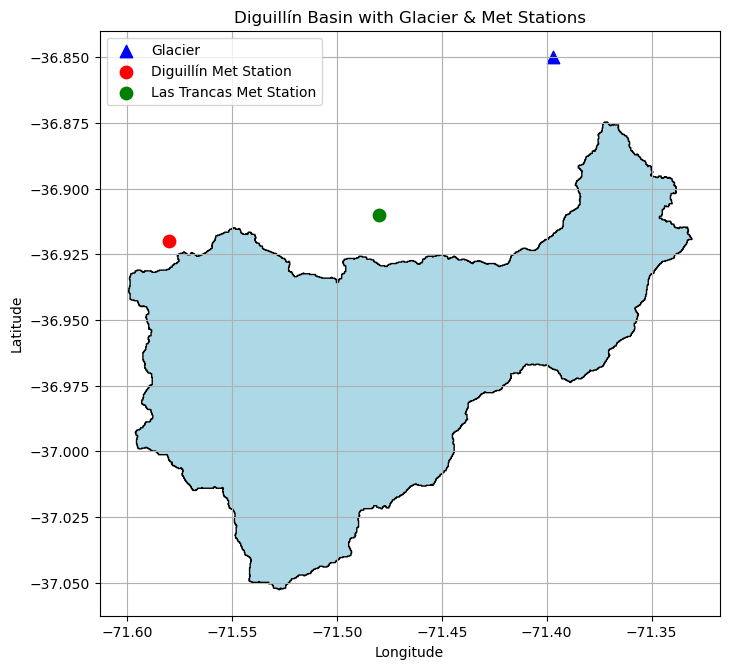

In [4]:
# path to basin shapefile
shapefile_path = '/Users/milliespencer/Desktop/70_Years_MB_Nevados/camels_cl_8130002/polygon/polygon.shp' 
# File paths for your CAMELS basin data
# Here using: Cuenca 8130002 - Rio Diguillin En San Lorenzo (Atacalco) (Lat. -36.92, Lon. -71.58)
# Área: 204.4 km². Precip. anual media CR2MET: 2400 mm. Indice áridez: 0.4
# Cota (máx., media, punto salida): 3176, 1511, 715 m s.n.m.

# Load the shapefile using GeoPandas
basin_gdf = gpd.read_file(shapefile_path)

# Glacier and station coordinates (lat, lon)
glacier_coords = (-36.85, -71.397)   # (Lat, Lon)
diguillin_station_coords = (-36.92, -71.58)    # (Lat, Lon)
trancas_station_coords = (-36.91, -71.48)    # (Lat, Lon)

# Elevations in meters
glacier_elev = 2614
station_elev_diguillin = 715
station_elev_trancas = 1248

# Calculate aerial distance (in km)
diguillin_distance_km = geodesic(glacier_coords, diguillin_station_coords).km
trancas_distance_km = geodesic(glacier_coords, trancas_station_coords).km

# Calculate elevation difference (in m)
elev_diff_diguillin = glacier_elev - station_elev_diguillin
elev_diff_trancas = glacier_elev - station_elev_trancas

print(f"Distance between glacier and Diguillin met station: {diguillin_distance_km:.2f} km")
print(f"Distance between glacier and Las Trancas met station: {trancas_distance_km:.2f} km")
print(f"Elevation difference Glacier to Diguillin: {elev_diff_diguillin} m")
print(f"Elevation difference Glacier to Las Trancas: {elev_diff_trancas} m")

# Plot the basin polygon
fig, ax = plt.subplots(figsize=(8, 8))
basin_gdf.plot(ax=ax, color='lightblue', edgecolor='black')

# Plot glacier location
ax.scatter(glacier_coords[1], glacier_coords[0], color='blue', s=80, marker='^', label="Glacier")

# Plot meteorological station location
ax.scatter(diguillin_station_coords[1], diguillin_station_coords[0], color='red', s=80, marker='o', label="Diguillín Met Station")
ax.scatter(trancas_station_coords[1], trancas_station_coords[0], color='green', s=80, marker='o', label="Las Trancas Met Station")


# Add labels and grid
ax.set_title("Diguillín Basin with Glacier & Met Stations")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True)
ax.legend()

plt.show()


## MAWUN precip comparison: (https://mawun.cr2.cl)
### Compares station data with CR2MET, IMERG, ERA5, CHIRPS, MSWEP, MSWX, and CMORPH

## First for Estación Diguillín 

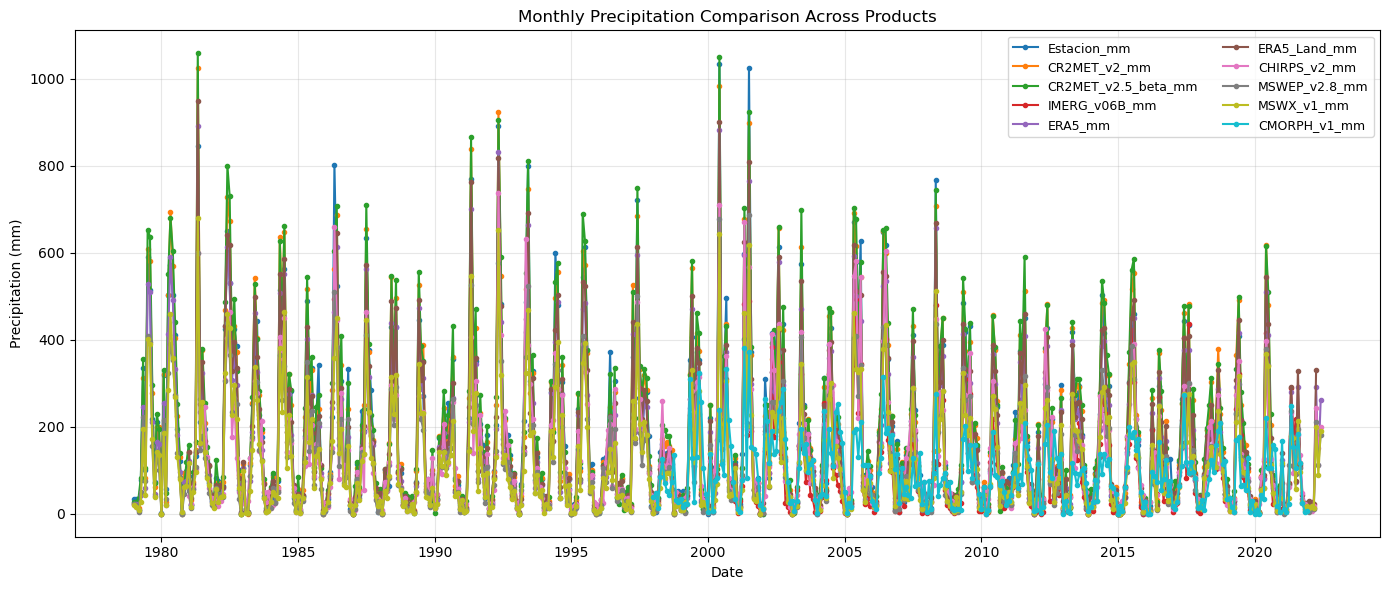

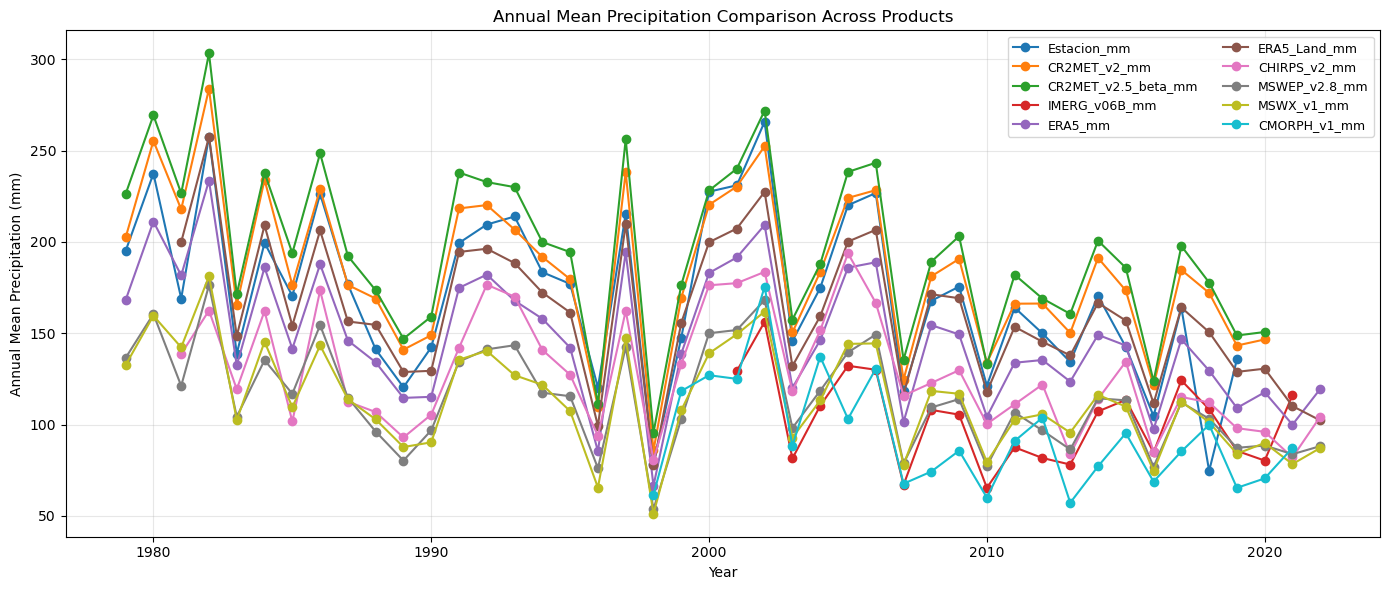


=== Mean Bias (mm) relative to reference station ===
Estacion_mm             0.000000
CR2MET_v2_mm           13.993496
CR2MET_v2.5_beta_mm    24.971138
IMERG_v06B_mm         -59.509649
ERA5_mm               -21.223984
ERA5_Land_mm           -4.583761
CHIRPS_v2_mm          -38.158547
MSWEP_v2.8_mm         -55.179268
MSWX_v1_mm            -55.597967
CMORPH_v1_mm          -65.576515
dtype: float64

Interpretation: Positive values indicate overestimation; negative values indicate underestimation relative to the station.

=== RMSE (mm) relative to reference station ===
CR2MET_v2_mm           22.921954
CR2MET_v2.5_beta_mm    30.512513
IMERG_v06B_mm          67.312720
ERA5_mm                27.808361
ERA5_Land_mm           19.433517
CHIRPS_v2_mm           44.849053
MSWEP_v2.8_mm          58.959312
MSWX_v1_mm             59.968919
CMORPH_v1_mm           73.491687
dtype: float64

Interpretation: Lower RMSE indicates better agreement with the reference station.

=== Correlation with reference s

In [5]:
# ------------------ FILE PATH ------------------
file_path = "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Diguillin_codigo[C08130006].csv"

# ------------------ LOAD DATA ------------------
# Read CSV with latin-1 encoding
df = pd.read_csv(file_path, encoding="latin-1")

# Replace missing value code (-9999) with NaN
df.replace(-9999, np.nan, inplace=True)

# Convert 'Fecha' column to datetime (monthly frequency)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%Y-%m')

# Identify precipitation products (all columns except 'Fecha')
products = [col for col in df.columns if col != 'Fecha']

# ------------------ MONTHLY TIME SERIES PLOT ------------------
plt.figure(figsize=(14,6))
for prod in products:
    plt.plot(df['Fecha'], df[prod], label=prod, marker='o', markersize=3)

plt.title("Monthly Precipitation Comparison Across Products")
plt.xlabel("Date")
plt.ylabel("Precipitation (mm)")
plt.legend(ncol=2, fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------ ANNUAL AGGREGATION ------------------
# Extract year from date
df['year'] = df['Fecha'].dt.year

# Compute annual mean for each product
annual_df = df.groupby('year')[products].mean()

# ------------------ ANNUAL TIME SERIES PLOT ------------------
plt.figure(figsize=(14,6))
for prod in products:
    plt.plot(annual_df.index, annual_df[prod], marker='o', label=prod)

plt.title("Annual Mean Precipitation Comparison Across Products")
plt.xlabel("Year")
plt.ylabel("Annual Mean Precipitation (mm)")
plt.legend(ncol=2, fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------ QUANTITATIVE COMPARISON ------------------
reference = 'Estacion_mm'  # Use station measurements as reference

# ---- 1. Mean Bias ----
# Difference between each product and reference station
bias = annual_df.subtract(annual_df[reference], axis=0)
mean_bias = bias.mean()  # Average bias over all years
print("\n=== Mean Bias (mm) relative to reference station ===")
print(mean_bias)
print("\nInterpretation: Positive values indicate overestimation; negative values indicate underestimation relative to the station.")

# ---- 2. RMSE ----
# Root Mean Squared Error relative to reference station
rmse_corrected = {}
for prod in products:
    if prod != reference:
        valid = annual_df[[reference, prod]].dropna()
        rmse_corrected[prod] = np.sqrt(np.mean((valid[prod] - valid[reference])**2))

rmse_corrected = pd.Series(rmse_corrected)
print("\n=== RMSE (mm) relative to reference station ===")
print(rmse_corrected)
print("\nInterpretation: Lower RMSE indicates better agreement with the reference station.")

# ---- 3. Correlation ----
# Pearson correlation coefficient relative to reference station
corr = annual_df.corr()[reference]
print("\n=== Correlation with reference station ===")
print(corr)
print("\nInterpretation: Values closer to 1 indicate stronger linear agreement with the station.")



### Here MSWEP performs best, followed by CR2MET 2.5 beta and then MSWX, ERA5 ... 

## Now for Estación Las Trancas

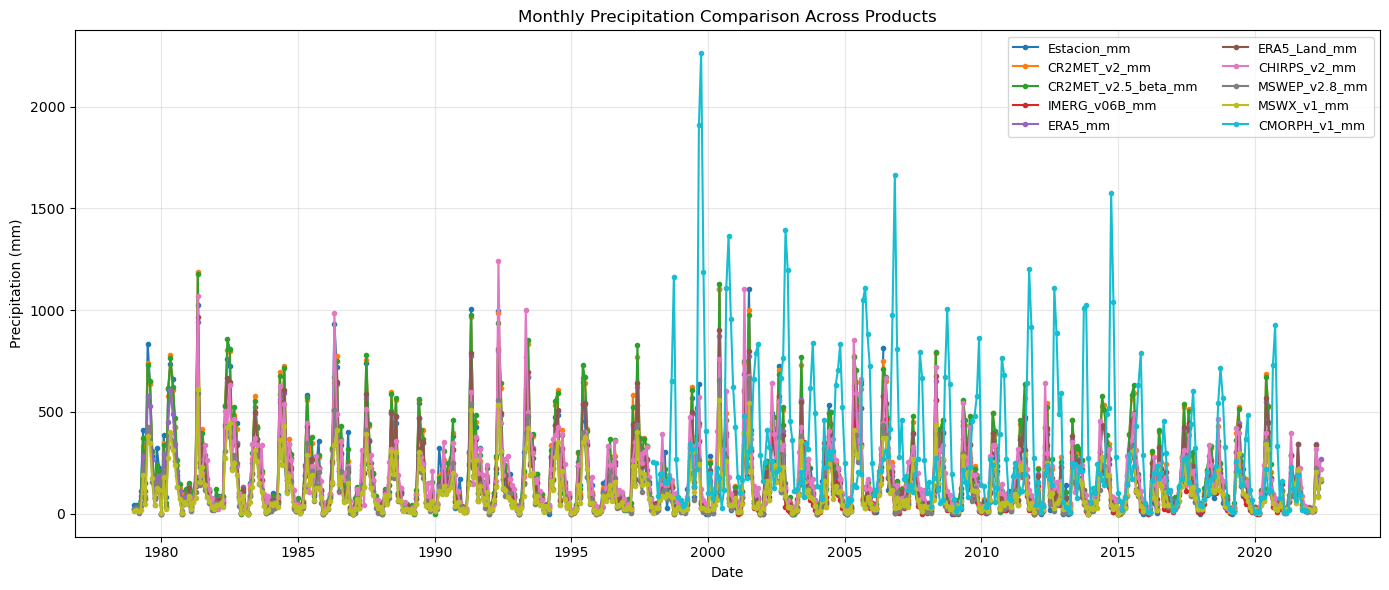

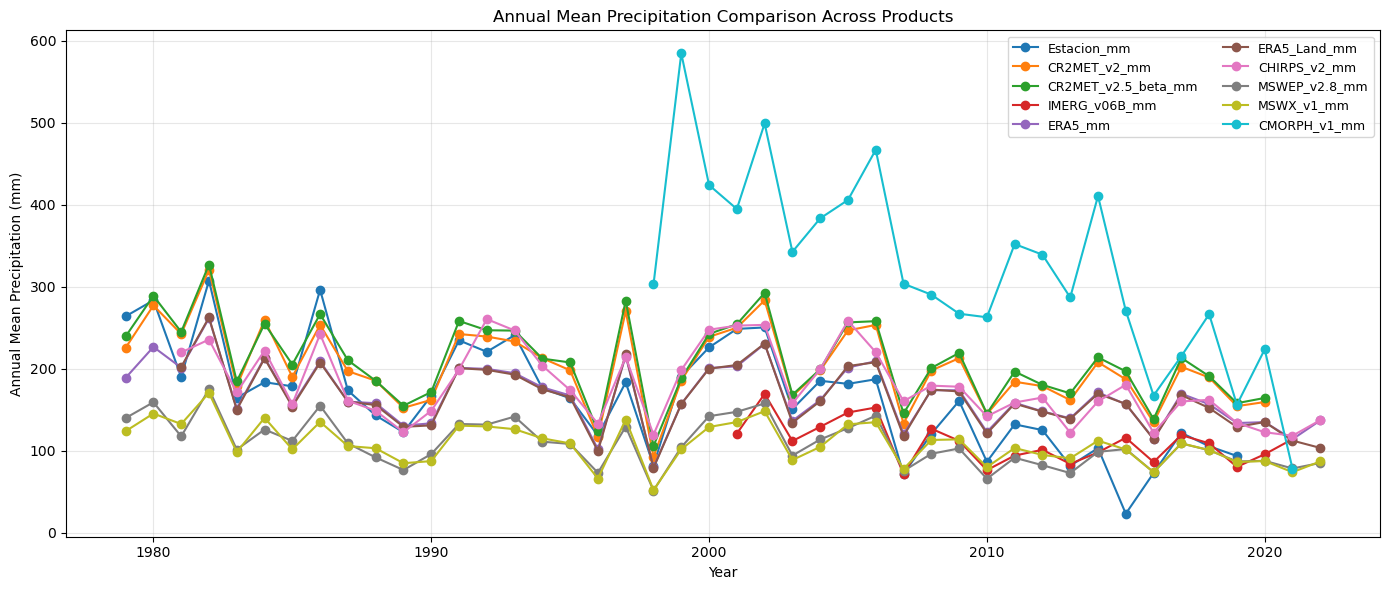


=== Mean Bias (mm) relative to reference station ===
Estacion_mm              0.000000
CR2MET_v2_mm            37.765001
CR2MET_v2.5_beta_mm     44.693863
IMERG_v06B_mm          -20.894463
ERA5_mm                  3.754838
ERA5_Land_mm             6.276454
CHIRPS_v2_mm            23.742266
MSWEP_v2.8_mm          -55.759389
MSWX_v1_mm             -55.730934
CMORPH_v1_mm           199.568418
dtype: float64

Interpretation: Positive values indicate overestimation; negative values indicate underestimation relative to the station.

=== RMSE (mm) relative to reference station ===
CR2MET_v2_mm            54.837253
CR2MET_v2.5_beta_mm     59.205981
IMERG_v06B_mm           47.810805
ERA5_mm                 42.710408
ERA5_Land_mm            40.873321
CHIRPS_v2_mm            45.567445
MSWEP_v2.8_mm           70.117616
MSWX_v1_mm              73.944028
CMORPH_v1_mm           212.683833
dtype: float64

Interpretation: Lower RMSE indicates better agreement with the reference station.

=== Correlati

In [6]:
# ------------------ FILE PATH ------------------
file_path = "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Las Trancas_codigo[C08130004].csv"

# ------------------ LOAD DATA ------------------
# Read CSV with latin-1 encoding
df = pd.read_csv(file_path, encoding="latin-1")

# Replace missing value code (-9999) with NaN
df.replace(-9999, np.nan, inplace=True)

# Convert 'Fecha' column to datetime (monthly frequency)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%Y-%m')

# Identify precipitation products (all columns except 'Fecha')
products = [col for col in df.columns if col != 'Fecha']

# ------------------ MONTHLY TIME SERIES PLOT ------------------
plt.figure(figsize=(14,6))
for prod in products:
    plt.plot(df['Fecha'], df[prod], label=prod, marker='o', markersize=3)

plt.title("Monthly Precipitation Comparison Across Products")
plt.xlabel("Date")
plt.ylabel("Precipitation (mm)")
plt.legend(ncol=2, fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------ ANNUAL AGGREGATION ------------------
# Extract year from date
df['year'] = df['Fecha'].dt.year

# Compute annual mean for each product
annual_df = df.groupby('year')[products].mean()

# ------------------ ANNUAL TIME SERIES PLOT ------------------
plt.figure(figsize=(14,6))
for prod in products:
    plt.plot(annual_df.index, annual_df[prod], marker='o', label=prod)

plt.title("Annual Mean Precipitation Comparison Across Products")
plt.xlabel("Year")
plt.ylabel("Annual Mean Precipitation (mm)")
plt.legend(ncol=2, fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------ QUANTITATIVE COMPARISON ------------------
reference = 'Estacion_mm'  # Use station measurements as reference

# ---- 1. Mean Bias ----
# Difference between each product and reference station
bias = annual_df.subtract(annual_df[reference], axis=0)
mean_bias = bias.mean()  # Average bias over all years
print("\n=== Mean Bias (mm) relative to reference station ===")
print(mean_bias)
print("\nInterpretation: Positive values indicate overestimation; negative values indicate underestimation relative to the station.")

# ---- 2. RMSE ----
# Root Mean Squared Error relative to reference station
rmse_corrected = {}
for prod in products:
    if prod != reference:
        valid = annual_df[[reference, prod]].dropna()
        rmse_corrected[prod] = np.sqrt(np.mean((valid[prod] - valid[reference])**2))

rmse_corrected = pd.Series(rmse_corrected)
print("\n=== RMSE (mm) relative to reference station ===")
print(rmse_corrected)
print("\nInterpretation: Lower RMSE indicates better agreement with the reference station.")

# ---- 3. Correlation ----
# Pearson correlation coefficient relative to reference station
corr = annual_df.corr()[reference]
print("\n=== Correlation with reference station ===")
print(corr)
print("\nInterpretation: Values closer to 1 indicate stronger linear agreement with the station.")

## Conducting changepoint analysis using R package ecp

In [6]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


## looking at annual precip, changepoint analysis and comparing pre- and post-2000:

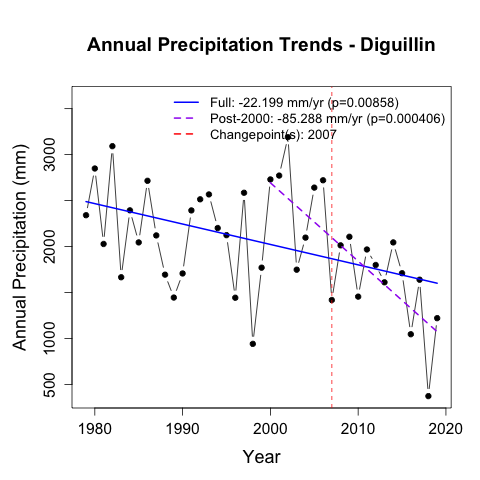

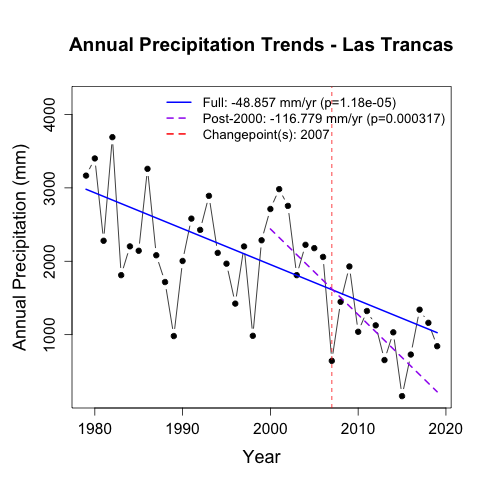

In [12]:
%%R
# ======================================================
# Loop over stations
# ======================================================
for(station_name in names(stations)) {
  
  file_path <- stations[[station_name]]
  
  # ---- Load data ----
  data <- read.csv(file_path)
  
  precip <- data[,2]
  precip[precip == -9999] <- NA
  
  dates <- as.Date(paste0(data[,1], "-01"), format="%Y-%m-%d")
  
  valid <- !is.na(precip)
  precip <- precip[valid]
  dates <- dates[valid]
  
  # ---- Annual totals ----
  years <- format(dates, "%Y")
  annual_precip <- tapply(precip, years, sum, na.rm=TRUE)
  annual_years <- as.numeric(names(annual_precip))
  
  # ---- Changepoints ----
  set.seed(123)
  result <- e.divisive(matrix(annual_precip, ncol=1), R=500, min.size=10)
  changepoint_years <- if(length(result$estimates) > 2) {
    annual_years[result$estimates[-c(1, length(result$estimates))]]
  } else NULL
  
  # ---- Pre/Post-2000 trends ----
  pre_index <- which(annual_years < 2000)
  post_index <- which(annual_years >= 2000)
  
  if (length(pre_index) > 5 && length(post_index) > 5) {
    slope_pre <- sens.slope(annual_precip[pre_index])$estimates
    p_pre <- MannKendall(annual_precip[pre_index])$sl
    
    slope_post <- sens.slope(annual_precip[post_index])$estimates
    p_post <- MannKendall(annual_precip[post_index])$sl
  } else {
    slope_pre <- slope_post <- NA
    p_pre <- p_post <- NA
  }
  
  # ---- Full-series trend ----
  slope_full <- sens.slope(annual_precip)$estimates
  p_full <- MannKendall(annual_precip)$sl
  
  # ---- Plot ----
  ylim_range <- range(annual_precip, na.rm=TRUE)
  ylim_range[2] <- ylim_range[2] + (0.15 * diff(ylim_range))
  
  par(mar=c(5,5,6,2))
  plot(annual_years, annual_precip, type="b", pch=19,
       main=paste("Annual Precipitation Trends -", station_name),
       xlab="Year", ylab="Annual Precipitation (mm)",
       ylim=ylim_range,
       cex.main=1.6, cex.axis=1.3, cex.lab=1.5)
  
  # Changepoints
  if(!is.null(changepoint_years)){
    abline(v=changepoint_years, col="red", lty=2)
  }
  
  legend_entries <- c()
  legend_cols <- c()
  legend_lty <- c()
  legend_lwd <- c()
  
  # Full-series
  if(p_full < 0.05){
    y_full_fit <- slope_full * annual_years + (median(annual_precip) - slope_full * median(annual_years))
    lines(annual_years, y_full_fit, col="blue", lwd=2)
    legend_entries <- c(legend_entries, paste0("Full: ", round(slope_full,3), " mm/yr (p=", signif(p_full,3), ")"))
    legend_cols <- c(legend_cols, "blue")
    legend_lty <- c(legend_lty, 1)
    legend_lwd <- c(legend_lwd, 2)
  }
  
  # Pre-2000
  if(!is.na(slope_pre) && p_pre < 0.05){
    x_pre <- annual_years[pre_index]
    y_pre_fit <- slope_pre * x_pre + (median(annual_precip[pre_index]) - slope_pre * median(x_pre))
    segments(min(x_pre), y_pre_fit[1], max(x_pre), y_pre_fit[length(y_pre_fit)],
             col="darkgreen", lwd=2, lty=2)
    legend_entries <- c(legend_entries, paste0("Pre-2000: ", round(slope_pre,3), " mm/yr (p=", signif(p_pre,3), ")"))
    legend_cols <- c(legend_cols, "darkgreen")
    legend_lty <- c(legend_lty, 2)
    legend_lwd <- c(legend_lwd, 2)
  }
  
  # Post-2000
  if(!is.na(slope_post) && p_post < 0.05){
    x_post <- annual_years[post_index]
    y_post_fit <- slope_post * x_post + (median(annual_precip[post_index]) - slope_post * median(x_post))
    segments(min(x_post), y_post_fit[1], max(x_post), y_post_fit[length(y_post_fit)],
             col="purple", lwd=2, lty=2)
    legend_entries <- c(legend_entries, paste0("Post-2000: ", round(slope_post,3), " mm/yr (p=", signif(p_post,3), ")"))
    legend_cols <- c(legend_cols, "purple")
    legend_lty <- c(legend_lty, 2)
    legend_lwd <- c(legend_lwd, 2)
  }
  
  # Legend for changepoints
  if(!is.null(changepoint_years)){
    legend_entries <- c(legend_entries, paste("Changepoint(s):", paste(changepoint_years, collapse=", ")))
    legend_cols <- c(legend_cols, "red")
    legend_lty <- c(legend_lty, 2)
    legend_lwd <- c(legend_lwd, 2)
  }
  
  legend("topright", legend=legend_entries, col=legend_cols,
         lty=legend_lty, lwd=legend_lwd, bty="n", cex=1.1)
  
}


## Now look at annual mean (min and max) temperatures, check for significant trend and changepoint(s):

The trend in mean annual max temperature is not significant, nor were any changepoints found. For min tempeature, however, four changepoints were found and the increasing trend was statistically significant (p<0.05)


Dataset: Tmax 
5 Lowest Years:
  Year Value
1 1965 16.33
2 1975 16.41
3 2007 16.63
4 2011 16.69
5 1976 16.77
5 Highest Years:
  Year Value
1 1996 18.95
2 1987 19.00
3 2013 19.12
4 1970 19.76
5 2016 19.98

Dataset: Tmin 
5 Lowest Years:
  Year Value
1 1976  4.39
2 1975  4.65
3 1988  4.67
4 1984  4.74
5 1979  4.83
5 Highest Years:
  Year Value
1 2001  7.12
2 1972  7.17
3 2012  7.17
4 2004  7.21
5 2005  7.27

Dataset: Tmean 
5 Lowest Years:
  Year Value
1 1975 10.53
2 1976 10.58
3 1965 10.79
4 1966 10.99
5 2007 11.02
5 Highest Years:
  Year Value
1 2005 12.70
2 1972 12.72
3 2013 12.77
4 1971 12.79
5 1970 13.26


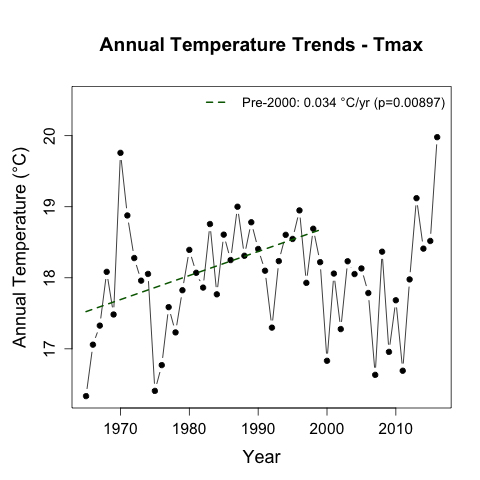

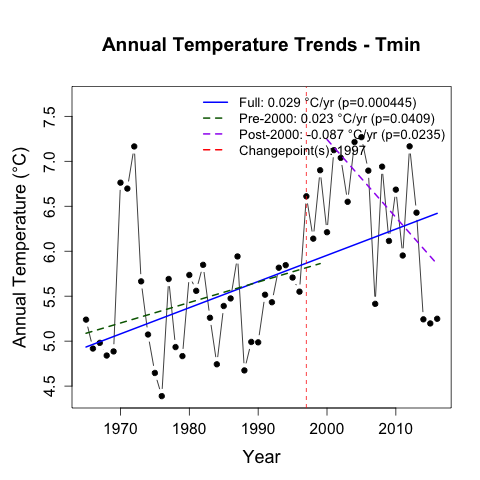

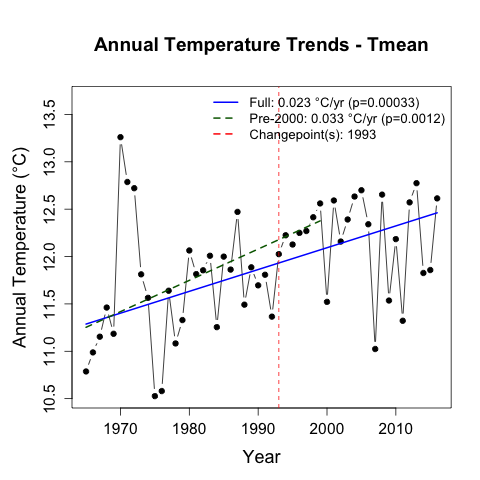

In [16]:
%%R
# =========================================================
# Changepoint and Trend Analysis for Annual Temperature
# =========================================================

# ---- Libraries ----
if(!require(ecp)) install.packages("ecp", repos='http://cran.us.r-project.org')
if(!require(trend)) install.packages("trend", repos='http://cran.us.r-project.org')
if(!require(Kendall)) install.packages("Kendall", repos='http://cran.us.r-project.org')

library(ecp)
library(trend)
library(Kendall)

# ---- File paths for Diguillin station ----
temp_files <- list(
  Tmax = "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/temp_max_diguillin.csv",
  Tmin = "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/temp_min_diguillin.csv"
)

# ---- Function to load temperature and aggregate to annual mean ----
load_temp_data <- function(file_path) {
  data <- read.csv(file_path, stringsAsFactors = FALSE)
  colnames(data) <- tolower(trimws(colnames(data)))
  
  if(!all(c("agno","mes","dia","valor") %in% colnames(data))) {
    stop(paste("Missing required columns in:", file_path))
  }
  
  data$date <- as.Date(paste(data$agno, data$mes, data$dia, sep="-"), format="%Y-%m-%d")
  data$valor[data$valor == -9999] <- NA
  data <- na.omit(data[, c("date", "valor")])
  data$year <- as.numeric(format(data$date, "%Y"))
  
  annual <- tapply(data$valor, data$year, mean, na.rm=TRUE)
  df <- data.frame(year = as.numeric(names(annual)), value = as.numeric(annual))
  return(df)
}

# ---- Load Tmax, Tmin, compute Tmean ----
tmax_df <- load_temp_data(temp_files$Tmax)
tmin_df <- load_temp_data(temp_files$Tmin)
common_years <- intersect(tmax_df$year, tmin_df$year)

tmax_df <- tmax_df[tmax_df$year %in% common_years, ]
tmin_df <- tmin_df[tmin_df$year %in% common_years, ]
tmean_df <- data.frame(year = common_years,
                       value = (tmax_df$value + tmin_df$value) / 2)

temp_datasets <- list(Tmax = tmax_df, Tmin = tmin_df, Tmean = tmean_df)

# ---- Analysis and plotting function ----
analyze_and_plot <- function(df, label, ylabel="Temperature (°C)") {
  years <- df$year
  vals <- df$value
  
  cat("\n=============================\n")
  cat("Dataset:", label, "\n")
  cat("=============================\n")
  
  # ---- Print 5 lowest and highest years ----
  sorted_indices <- order(vals)
  cat("5 Lowest Years:\n")
  print(data.frame(Year = years[sorted_indices[1:5]], Value = round(vals[sorted_indices[1:5]],2)))
  cat("5 Highest Years:\n")
  print(data.frame(Year = years[sorted_indices[(length(sorted_indices)-4):length(sorted_indices)]],
                   Value = round(vals[sorted_indices[(length(sorted_indices)-4):length(sorted_indices)]],2)))
  
  # ---- Changepoint detection ----
  set.seed(123)
  result <- e.divisive(matrix(vals, ncol=1), R=500, min.size=10)
  changepoint_years <- if(length(result$estimates) > 2) {
    years[result$estimates[-c(1, length(result$estimates))]]
  } else NULL
  
  # ---- Pre/Post-2000 trends ----
  pre_index <- which(years < 2000)
  post_index <- which(years >= 2000)
  
  if(length(pre_index) > 5 && length(post_index) > 5) {
    slope_pre <- sens.slope(vals[pre_index])$estimates
    p_pre <- MannKendall(vals[pre_index])$sl
    
    slope_post <- sens.slope(vals[post_index])$estimates
    p_post <- MannKendall(vals[post_index])$sl
  } else {
    slope_pre <- slope_post <- NA
    p_pre <- p_post <- NA
  }
  
  # ---- Full-series trend ----
  slope_full <- sens.slope(vals)$estimates
  p_full <- MannKendall(vals)$sl
  
  # ---- Plot ----
  ylim_range <- range(vals, na.rm=TRUE)
  ylim_range[2] <- ylim_range[2] + 0.15 * diff(ylim_range)
  
  par(mar=c(5,5,6,2))
  plot(years, vals, type="b", pch=19,
       main=paste("Annual Temperature Trends -", label),
       xlab="Year", ylab=ylabel,
       ylim=ylim_range,
       cex.axis=1.3, cex.lab=1.5, cex.main=1.6)
  
  legend_entries <- c()
  legend_cols <- c()
  legend_lty <- c()
  legend_lwd <- c()
  
  # ---- Full-series trendline ----
  if(p_full < 0.05){
    y_full_fit <- slope_full * years + (median(vals) - slope_full * median(years))
    lines(years, y_full_fit, col="blue", lwd=2)
    legend_entries <- c(legend_entries, paste0("Full: ", round(slope_full,3), " °C/yr (p=", signif(p_full,3), ")"))
    legend_cols <- c(legend_cols, "blue")
    legend_lty <- c(legend_lty, 1)
    legend_lwd <- c(legend_lwd, 2)
  }
  
  # ---- Pre-2000 ----
  if(!is.na(slope_pre) && p_pre < 0.05){
    x_pre <- years[pre_index]
    y_pre_fit <- slope_pre * x_pre + (median(vals[pre_index]) - slope_pre * median(x_pre))
    segments(min(x_pre), y_pre_fit[1], max(x_pre), y_pre_fit[length(y_pre_fit)],
             col="darkgreen", lwd=2, lty=2)
    legend_entries <- c(legend_entries, paste0("Pre-2000: ", round(slope_pre,3), " °C/yr (p=", signif(p_pre,3), ")"))
    legend_cols <- c(legend_cols, "darkgreen")
    legend_lty <- c(legend_lty, 2)
    legend_lwd <- c(legend_lwd, 2)
  }
  
  # ---- Post-2000 ----
  if(!is.na(slope_post) && p_post < 0.05){
    x_post <- years[post_index]
    y_post_fit <- slope_post * x_post + (median(vals[post_index]) - slope_post * median(x_post))
    segments(min(x_post), y_post_fit[1], max(x_post), y_post_fit[length(y_post_fit)],
             col="purple", lwd=2, lty=2)
    legend_entries <- c(legend_entries, paste0("Post-2000: ", round(slope_post,3), " °C/yr (p=", signif(p_post,3), ")"))
    legend_cols <- c(legend_cols, "purple")
    legend_lty <- c(legend_lty, 2)
    legend_lwd <- c(legend_lwd, 2)
  }
  
  # ---- Changepoints ----
  if(!is.null(changepoint_years)){
    abline(v=changepoint_years, col="red", lty=2)
    legend_entries <- c(legend_entries, paste("Changepoint(s):", paste(changepoint_years, collapse=", ")))
    legend_cols <- c(legend_cols, "red")
    legend_lty <- c(legend_lty, 2)
    legend_lwd <- c(legend_lwd, 2)
  }
  
  legend("topright", legend=legend_entries, col=legend_cols,
         lty=legend_lty, lwd=legend_lwd, bty="n", cex=1.1)
}

# ---- Run analysis for Tmax, Tmin, Tmean ----
for(name in names(temp_datasets)){
  analyze_and_plot(temp_datasets[[name]], name, ylabel="Annual Temperature (°C)")
}


## comparing modeled with measured precip products, still only Las Trancas station shows changepoint: 


Station: Diguillin , Variable: Estacion_mm 
Sen's slope: -22.82 mm/yr, M-K p-value: 0.0104 
Changepoints detected at years: 2007 

Station: Diguillin , Variable: CR2MET_v2_mm 
Sen's slope: -18.17 mm/yr, M-K p-value: 0.0189 
No changepoints detected.

Station: Diguillin , Variable: CR2MET_v2.5_beta_mm 
Sen's slope: -20.17 mm/yr, M-K p-value: 0.0148 
No changepoints detected.

Station: Diguillin , Variable: MSWEP_v2.8_mm 
Sen's slope: -13.15 mm/yr, M-K p-value: 0.00147 
Changepoints detected at years: 2007 

Station: Las Trancas , Variable: Estacion_mm 
Sen's slope: -47.57 mm/yr, M-K p-value: 3.35e-05 
Changepoints detected at years: 2007 

Station: Las Trancas , Variable: CR2MET_v2_mm 
Sen's slope: -21.6 mm/yr, M-K p-value: 0.0122 
No changepoints detected.

Station: Las Trancas , Variable: CR2MET_v2.5_beta_mm 
Sen's slope: -20.73 mm/yr, M-K p-value: 0.0115 
No changepoints detected.

Station: Las Trancas , Variable: MSWEP_v2.8_mm 
Sen's slope: -14.53 mm/yr, M-K p-value: 0.000697 
Chan

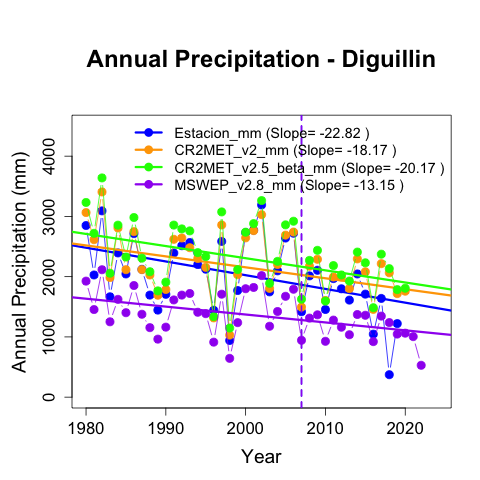

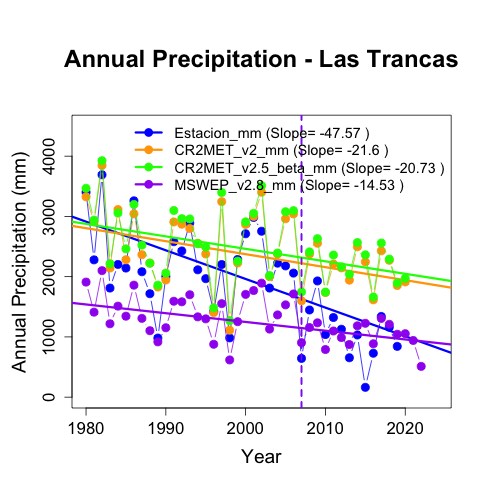

In [9]:
%%R
# ===============================
# Libraries
# ===============================
if(!require(trend)) install.packages("trend", repos='http://cran.us.r-project.org')
if(!require(Kendall)) install.packages("Kendall", repos='http://cran.us.r-project.org')
if(!require(ecp)) install.packages("ecp", repos='http://cran.us.r-project.org')

library(trend)
library(Kendall)
library(ecp)

# ===============================
# Increase plot size (wider)
# ===============================
options(repr.plot.width=18, repr.plot.height=10)  # wider plot

# ===============================
# Stations and variables
# ===============================
stations <- list(
  "Diguillin" = "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Diguillin_codigo[C08130006].csv",
  "Las Trancas" = "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Las Trancas_codigo[C08130004].csv"
)

variables <- c("Estacion_mm", "CR2MET_v2_mm", "CR2MET_v2.5_beta_mm", "MSWEP_v2.8_mm")
colors <- c("blue", "orange", "green", "purple")

# ===============================
# Loop over stations
# ===============================
for(station_name in names(stations)){
  
  file_path <- stations[[station_name]]
  data <- read.csv(file_path, stringsAsFactors = FALSE)
  
  # Hard-code y-axis to 0–4500 mm, extra space on top for legend
  ylim_range <- c(0, 4500)
  
  # Open empty plot with larger top margin
  par(mar=c(5,5,8,2))  # more space at top
  plot(NULL, xlim=c(1980, 2024), ylim=ylim_range,
       xlab="Year", ylab="Annual Precipitation (mm)",
       main=paste("Annual Precipitation -", station_name),
       cex.main=2, cex.lab=1.6, cex.axis=1.4)
  
  legend_labels <- c()
  
  for(i in seq_along(variables)){
    varname <- variables[i]
    
    if(!varname %in% names(data)){
      cat("\nStation:", station_name, "Variable:", varname, "- not found, skipping.\n")
      next
    }
    
    # Extract variable and clean
    values <- as.numeric(data[[varname]])
    dates <- as.Date(paste0(data[,1], "-01"), format="%Y-%m-%d")
    valid_idx <- !is.na(values) & values != -9999 & format(dates, "%Y") >= 1980
    values <- values[valid_idx]
    dates <- dates[valid_idx]
    
    # Aggregate to annual totals
    years <- as.numeric(format(dates, "%Y"))
    annual_precip <- tapply(values, years, sum, na.rm=TRUE)
    annual_years <- as.numeric(names(annual_precip))
    
    # ---- Sen's slope + Mann-Kendall ----
    slope_obj <- sens.slope(annual_precip)
    slope <- slope_obj$estimates
    intercept <- median(annual_precip) - slope * median(annual_years)
    
    mk_res <- MannKendall(annual_precip)
    pval <- mk_res$sl
    
    # ---- Changepoint detection with min 10-year spacing ----
    set.seed(123)
    cp_result <- e.divisive(matrix(annual_precip, ncol=1), R=500, min.size=10)
    
    if(length(cp_result$estimates) > 2){
      cp_indices <- cp_result$estimates[-c(1,length(cp_result$estimates))]
      cp_years <- annual_years[cp_indices]
    } else {
      cp_indices <- NULL
      cp_years <- NULL
    }
    
    # ---- Print results ----
    cat("\nStation:", station_name, ", Variable:", varname, "\n")
    cat("Sen's slope:", round(slope,2), "mm/yr, M-K p-value:", signif(pval,3), "\n")
    if(!is.null(cp_years)){
      cat("Changepoints detected at years:", paste(cp_years, collapse=", "), "\n")
    } else {
      cat("No changepoints detected.\n")
    }
    
    # ---- Plot points and slope line ----
    points(annual_years, annual_precip, type="b", pch=19, col=colors[i], cex=1.5)
    abline(intercept, slope, col=colors[i], lwd=3)
    if(!is.null(cp_years)){
      abline(v=cp_years, col=colors[i], lty=2, lwd=2)
    }
    
    legend_labels <- c(legend_labels, paste(varname, "(Slope=", round(slope,2), ")"))
  }
  
  # ---- Add legend (smaller font) ----
  legend("topright", legend=legend_labels, col=colors[1:length(legend_labels)],
         lty=1, lwd=3, pch=19, bty="n", cex=1.2)
}


## now look at annual streamflow data:


Dataset: Río Diguillín 
5 Lowest Years:
  Year Flow_m3_s
1 2020     286.5
2 2015     977.3
3 2016    2235.5
4 1998    2288.8
5 1968    2438.8
5 Highest Years:
  Year Flow_m3_s
1 1980    8778.7
2 1951    8850.9
3 1950    9213.1
4 1982    9248.6
5 1972   10326.4


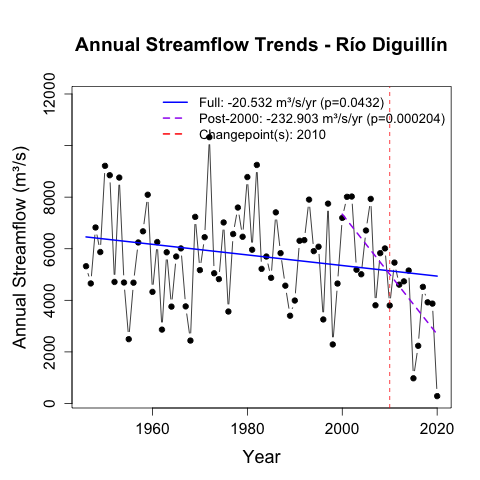

In [17]:
%%R
# =========================================================
# Annual Streamflow Trend Analysis - Río Diguillín
# =========================================================

# ---- Libraries ----
if(!require(ecp)) install.packages("ecp", repos='http://cran.us.r-project.org')
if(!require(trend)) install.packages("trend", repos='http://cran.us.r-project.org')
if(!require(Kendall)) install.packages("Kendall", repos='http://cran.us.r-project.org')

library(ecp)
library(trend)
library(Kendall)

# ---- File path ----
file_path <- "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/streamflow_diguillin.csv"

# ---- Load and prepare data ----
data <- read.csv(file_path, stringsAsFactors = FALSE)
colnames(data) <- tolower(trimws(colnames(data)))

if(!all(c("agno","mes","dia","valor") %in% colnames(data))) {
  stop("Missing required columns: agno, mes, dia, valor")
}

data$date <- as.Date(paste(data$agno, data$mes, data$dia, sep="-"), format="%Y-%m-%d")
data$valor[data$valor == -9999] <- NA
data <- na.omit(data)

# ---- Aggregate to annual streamflow totals ----
annual_flow <- aggregate(data$valor, by=list(Year=data$agno), FUN=sum, na.rm=TRUE)
colnames(annual_flow) <- c("year", "flow")
annual_flow <- annual_flow[order(annual_flow$year), ]

# ---- Trend & Changepoint Analysis Function ----
analyze_annual_streamflow <- function(df, label="Annual Streamflow") {
  years <- df$year
  flows <- df$flow
  
  cat("\n=============================\n")
  cat("Dataset:", label, "\n")
  cat("=============================\n")
  
  # Print 5 lowest and highest years
  sorted_idx <- order(flows)
  cat("5 Lowest Years:\n")
  print(data.frame(Year=years[sorted_idx[1:5]], Flow_m3_s=round(flows[sorted_idx[1:5]],2)))
  cat("5 Highest Years:\n")
  print(data.frame(Year=years[sorted_idx[(length(sorted_idx)-4):length(sorted_idx)]],
                   Flow_m3_s=round(flows[sorted_idx[(length(sorted_idx)-4):length(sorted_idx)]],2)))
  
  # ---- Changepoints ----
  set.seed(123)
  cp <- e.divisive(matrix(flows, ncol=1), R=500, min.size=10)
  changepoints <- if(length(cp$estimates) > 2) years[cp$estimates[-c(1,length(cp$estimates))]] else NULL
  
  # ---- Pre/Post-2000 trends ----
  pre_idx <- which(years < 2000)
  post_idx <- which(years >= 2000)
  
  if(length(pre_idx) > 5 && length(post_idx) > 5){
    slope_pre <- sens.slope(flows[pre_idx])$estimates
    p_pre <- MannKendall(flows[pre_idx])$sl
    
    slope_post <- sens.slope(flows[post_idx])$estimates
    p_post <- MannKendall(flows[post_idx])$sl
  } else {
    slope_pre <- slope_post <- NA
    p_pre <- p_post <- NA
  }
  
  # ---- Full-series trend ----
  slope_full <- sens.slope(flows)$estimates
  p_full <- MannKendall(flows)$sl
  
  # ---- Plot ----
  ylim_range <- range(flows, na.rm=TRUE)
  ylim_range[2] <- ylim_range[2] + 0.15*diff(ylim_range)
  
  par(mar=c(5,5,6,2))
  plot(years, flows, type="b", pch=19,
       main=paste("Annual Streamflow Trends -", label),
       xlab="Year", ylab="Annual Streamflow (m³/s)",
       ylim=ylim_range,
       cex.axis=1.3, cex.lab=1.5, cex.main=1.6)
  
  legend_entries <- c()
  legend_cols <- c()
  legend_lty <- c()
  legend_lwd <- c()
  
  # Full-series
  if(p_full < 0.05){
    y_fit <- slope_full*years + (median(flows) - slope_full*median(years))
    lines(years, y_fit, col="blue", lwd=2)
    legend_entries <- c(legend_entries, paste0("Full: ", round(slope_full,3), " m³/s/yr (p=", signif(p_full,3),")"))
    legend_cols <- c(legend_cols, "blue")
    legend_lty <- c(legend_lty,1)
    legend_lwd <- c(legend_lwd,2)
  }
  
  # Pre-2000
  if(!is.na(slope_pre) && p_pre<0.05){
    x_pre <- years[pre_idx]
    y_pre <- slope_pre*x_pre + (median(flows[pre_idx]) - slope_pre*median(x_pre))
    segments(min(x_pre), y_pre[1], max(x_pre), y_pre[length(y_pre)], col="darkgreen", lwd=2, lty=2)
    legend_entries <- c(legend_entries, paste0("Pre-2000: ", round(slope_pre,3), " m³/s/yr (p=", signif(p_pre,3),")"))
    legend_cols <- c(legend_cols,"darkgreen")
    legend_lty <- c(legend_lty,2)
    legend_lwd <- c(legend_lwd,2)
  }
  
  # Post-2000
  if(!is.na(slope_post) && p_post<0.05){
    x_post <- years[post_idx]
    y_post <- slope_post*x_post + (median(flows[post_idx]) - slope_post*median(x_post))
    segments(min(x_post), y_post[1], max(x_post), y_post[length(y_post)], col="purple", lwd=2, lty=2)
    legend_entries <- c(legend_entries, paste0("Post-2000: ", round(slope_post,3), " m³/s/yr (p=", signif(p_post,3),")"))
    legend_cols <- c(legend_cols,"purple")
    legend_lty <- c(legend_lty,2)
    legend_lwd <- c(legend_lwd,2)
  }
  
  # Changepoints
  if(!is.null(changepoints)){
    abline(v=changepoints, col="red", lty=2)
    legend_entries <- c(legend_entries, paste("Changepoint(s):", paste(changepoints, collapse=", ")))
    legend_cols <- c(legend_cols,"red")
    legend_lty <- c(legend_lty,2)
    legend_lwd <- c(legend_lwd,2)
  }
  
  legend("topright", legend=legend_entries, col=legend_cols,
         lty=legend_lty, lwd=legend_lwd, bty="n", cex=1.1)
}

# ---- Run analysis ----
analyze_annual_streamflow(annual_flow, label="Río Diguillín")


## Now looking at summertime trends: 

## Streamflow

In [32]:
%%R 
install.packages("dplyr", repos='http://cran.us.r-project.org')


* installing *source* package ‘dplyr’ ...
** package ‘dplyr’ successfully unpacked and MD5 sums checked
** using staged installation
** libs
using C++ compiler: ‘clang version 20.1.3’
using SDK: ‘’


arm64-apple-darwin20.0.0-clang++ -std=gnu++17 -I"/Users/milliespencer/miniconda3/envs/glacier-env/lib/R/include" -DNDEBUG   -D_FORTIFY_SOURCE=2 -isystem /Users/milliespencer/miniconda3/envs/glacier-env/include -mmacosx-version-min=11.0 -mmacosx-version-min=11.0 -I/Users/milliespencer/miniconda3/envs/glacier-env/include    -fPIC  -ftree-vectorize -fPIC -fstack-protector-strong -O2 -pipe -stdlib=libc++ -fvisibility-inlines-hidden -fmessage-length=0 -isystem /Users/milliespencer/miniconda3/envs/glacier-env/include -fdebug-prefix-map=/Users/runner/miniforge3/conda-bld/r-base-split_1740766746684/work=/usr/local/src/conda/r-base-4.4.3 -fdebug-prefix-map=/Users/milliespencer/miniconda3/envs/glacier-env=/usr/local/src/conda-prefix   -c chop.cpp -o chop.o
arm64-apple-darwin20.0.0-clang++ -std=gnu++17 -I"/Users/milliespencer/miniconda3/envs/glacier-env/lib/R/include" -DNDEBUG   -D_FORTIFY_SOURCE=2 -isystem /Users/milliespencer/miniconda3/envs/glacier-env/include -mmacosx-version-min=11.0 -mmacos

installing to /Users/milliespencer/miniconda3/envs/glacier-env/lib/R/library/00LOCK-dplyr/00new/dplyr/libs
** R
** data
*** moving datasets to lazyload DB
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
*** copying figures
** building package indices
** installing vignettes
** testing if installed package can be loaded from temporary location
** checking absolute paths in shared objects and dynamic libraries
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
* DONE (dplyr)


trying URL 'http://cran.us.r-project.org/src/contrib/dplyr_1.1.4.tar.gz'
Content type 'application/x-gzip' length 1207521 bytes (1.2 MB)
downloaded 1.2 MB


The downloaded source packages are in
	‘/private/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/RtmpnLRqii/downloaded_packages’
Updating HTML index of packages in '.Library'
Making 'packages.html' ... done


In [52]:
%%R
# =========================================================
# Streamflow Monthly Winter Analysis: Dec, Jan, Feb (3x1 PNG)
# =========================================================

# ---- Libraries ----
if(!require(ecp)) install.packages("ecp", repos='http://cran.us.r-project.org')
if(!require(trend)) install.packages("trend", repos='http://cran.us.r-project.org')
if(!require(Kendall)) install.packages("Kendall", repos='http://cran.us.r-project.org')
if(!require(dplyr)) install.packages("dplyr", repos='http://cran.us.r-project.org')

library(ecp)
library(trend)
library(Kendall)
library(dplyr)

# ---- Load Streamflow Data ----
stream_file <- "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/streamflow_diguillin.csv"
stream_df <- read.csv(stream_file)
stream_df$valor[stream_df$valor == -9999] <- NA
stream_df$date <- as.Date(paste(stream_df$agno, stream_df$mes, stream_df$dia, sep="-"))
stream_df$month <- as.numeric(format(stream_df$date,"%m"))
stream_df$year <- as.numeric(format(stream_df$date,"%Y"))
# December counts toward next winter_year
stream_df$winter_year <- stream_df$year
stream_df$winter_year[stream_df$month == 12] <- stream_df$year[stream_df$month == 12] + 1

# ---- Analysis Function ----
analyze_month <- function(df, month_num, dataset_label){
  month_df <- subset(df, month == month_num)
  if(nrow(month_df) == 0) return(NULL)
  
  agg_df <- month_df %>%
    group_by(winter_year) %>%
    summarise(valor = mean(valor, na.rm=TRUE))
  
  values <- agg_df$valor
  years <- agg_df$winter_year
  
  # Changepoints
  set.seed(123)
  cp <- e.divisive(matrix(values, ncol=1), R=100, min.size=10)
  changepoints <- if(length(cp$estimates) > 2) years[cp$estimates[-c(1,length(cp$estimates))]] else NULL
  
  # Pre/post 2000 slopes
  pre_idx <- which(years < 2000)
  post_idx <- which(years >= 2000)
  slope_pre <- p_pre <- slope_post <- p_post <- NA
  if(length(pre_idx) > 5){ slope_pre <- sens.slope(values[pre_idx])$estimates; p_pre <- MannKendall(values[pre_idx])$sl }
  if(length(post_idx) > 5){ slope_post <- sens.slope(values[post_idx])$estimates; p_post <- MannKendall(values[post_idx])$sl }
  slope_full <- sens.slope(values)$estimates
  p_full <- MannKendall(values)$sl
  
  # Plot
  ylim_range <- range(values, na.rm=TRUE)
  ylim_range[2] <- ylim_range[2] + 0.15*diff(ylim_range)
  plot(years, values, type="b", pch=19,
       main=paste(dataset_label, "-", month.abb[month_num]),
       xlab="Year", ylab="Streamflow (m³/s)",
       ylim=ylim_range, cex.axis=1.3, cex.lab=1.5, cex.main=1.6)
  
  if(p_full < 0.05) lines(years, slope_full*years + (median(values)-slope_full*median(years)), col="blue", lwd=2)
  if(!is.na(slope_pre) && p_pre < 0.05){
    x_pre <- years[pre_idx]; y_pre <- slope_pre*x_pre + (median(values[pre_idx])-slope_pre*median(x_pre))
    segments(min(x_pre), y_pre[1], max(x_pre), y_pre[length(y_pre)], col="darkgreen", lwd=2, lty=2)
  }
  if(!is.na(slope_post) && p_post < 0.05){
    x_post <- years[post_idx]; y_post <- slope_post*x_post + (median(values[post_idx])-slope_post*median(x_post))
    segments(min(x_post), y_post[1], max(x_post), y_post[length(y_post)], col="purple", lwd=2, lty=2)
  }
  if(!is.null(changepoints)) abline(v=changepoints, col="red", lty=2)
  
  # Legend
  legend_entries <- c(); legend_cols <- c(); legend_lty <- c(); legend_lwd <- c()
  if(p_full < 0.05){ legend_entries <- c(legend_entries, paste0("Full: ", round(slope_full,3), " (p=", signif(p_full,3),")")); legend_cols <- c(legend_cols,"blue"); legend_lty <- c(legend_lty,1); legend_lwd <- c(legend_lwd,2)}
  if(!is.na(slope_pre) && p_pre < 0.05){ legend_entries <- c(legend_entries, paste0("Pre-2000: ", round(slope_pre,3), " (p=", signif(p_pre,3),")")); legend_cols <- c(legend_cols,"darkgreen"); legend_lty <- c(legend_lty,2); legend_lwd <- c(legend_lwd,2)}
  if(!is.na(slope_post) && p_post < 0.05){ legend_entries <- c(legend_entries, paste0("Post-2000: ", round(slope_post,3), " (p=", signif(p_post,3),")")); legend_cols <- c(legend_cols,"purple"); legend_lty <- c(legend_lty,2); legend_lwd <- c(legend_lwd,2)}
  if(!is.null(changepoints)){ legend_entries <- c(legend_entries, paste("Changepoints:", paste(changepoints, collapse=", "))); legend_cols <- c(legend_cols,"red"); legend_lty <- c(legend_lty,2); legend_lwd <- c(legend_lwd,2)}
  if(length(legend_entries) > 0){ legend("topright", legend=legend_entries, col=legend_cols, lty=legend_lty, lwd=legend_lwd, bty="n", cex=1.1) }
}

# ---- Save as High-Res PNG (3x1) ----
png("/Users/milliespencer/Desktop/streamflow_winter_3x1.png", width=3000, height=1200, res=300)  # 3x1 high-res
par(mfrow=c(1,3), mar=c(4,4,3,1))  # 3 panels side by side

for(m in c(12,1,2)){
  analyze_month(stream_df, m, "Streamflow - Río Diguillín")
}

dev.off()  # Close device


quartz_off_screen 
                2 


## Precip

In [ ]:
%%R
# =========================================================
# Precipitation Summer Analysis: Combined 2x3 Figure
# =========================================================

# ---- Libraries ----
if(!require(ecp)) install.packages("ecp", repos='http://cran.us.r-project.org')
if(!require(trend)) install.packages("trend", repos='http://cran.us.r-project.org')
if(!require(Kendall)) install.packages("Kendall", repos='http://cran.us.r-project.org')
if(!require(dplyr)) install.packages("dplyr", repos='http://cran.us.r-project.org')

library(ecp)
library(trend)
library(Kendall)
library(dplyr)

# ---- File paths ----
stations <- list(
  Diguillin = "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Diguillin_codigo[C08130006].csv",
  LasTrancas = "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Las Trancas_codigo[C08130004].csv"
)

# ---- Loader for precip (matches your CSV) ----
load_precip <- function(file_path){
  df <- read.csv(file_path, stringsAsFactors=FALSE)
  precip <- df[,2]
  precip[precip == -9999] <- NA
  dates <- as.Date(paste0(df[,1], "-01"), format="%Y-%m-%d")
  month <- as.numeric(format(dates, "%m"))
  year <- as.numeric(format(dates, "%Y"))
  summer_year <- year
  summer_year[month==12] <- year[month==12] + 1
  return(data.frame(date=dates, valor=precip, month=month, year=year, summer_year=summer_year))
}

# ---- Analysis and Plotting Function ----
analyze_month <- function(df, month_num, dataset_label){
  month_df <- subset(df, month==month_num)
  if(nrow(month_df)==0) return(NULL)
  
  # Compute summer-year averages
  agg_df <- month_df %>%
    group_by(summer_year) %>%
    summarise(valor=mean(valor, na.rm=TRUE))
  
  values <- agg_df$valor
  years <- agg_df$summer_year
  
  # Remove NAs
  valid_idx <- which(!is.na(values))
  if(length(valid_idx) < 10) return(NULL) # not enough data to analyze
  
  values <- values[valid_idx]
  years <- years[valid_idx]
  
  # ---- Changepoints ----
  changepoints <- NULL
  if(length(values) >= 10){
    set.seed(123)
    cp <- e.divisive(matrix(values, ncol=1), R=500, min.size=10)
    if(length(cp$estimates) > 2){
      changepoints <- years[cp$estimates[-c(1,length(cp$estimates))]]
    }
  }
  
  # ---- Pre/post 2000 trends ----
  pre_idx <- which(years < 2000)
  post_idx <- which(years >= 2000)
  
  slope_pre <- p_pre <- slope_post <- p_post <- NA
  if(length(pre_idx) > 5){
    slope_pre <- sens.slope(values[pre_idx])$estimates
    p_pre <- MannKendall(values[pre_idx])$sl
  }
  if(length(post_idx) > 5){
    slope_post <- sens.slope(values[post_idx])$estimates
    p_post <- MannKendall(values[post_idx])$sl
  }
  slope_full <- sens.slope(values)$estimates
  p_full <- MannKendall(values)$sl
  
  # ---- Plot ----
  ylim_range <- range(values, na.rm=TRUE)
  ylim_range[2] <- ylim_range[2] + 0.15*diff(ylim_range)
  
  plot(years, values, type="b", pch=19,
       main=paste(dataset_label, "-", month.abb[month_num]),
       xlab="Year", ylab="Precipitation (mm)",
       ylim=ylim_range, cex.axis=1.3, cex.lab=1.5, cex.main=1.4)
  
  # Full trend (only if significant)
  if(!is.na(slope_full) && p_full < 0.05){
    lines(years, slope_full*years + (median(values)-slope_full*median(years)),
          col="blue", lwd=2)
  }
  
  # Pre-2000 trend
  if(!is.na(slope_pre) && p_pre < 0.05){
    x_pre <- years[pre_idx]
    y_pre <- slope_pre*x_pre + (median(values[pre_idx]) - slope_pre*median(x_pre))
    segments(min(x_pre), y_pre[1], max(x_pre), y_pre[length(y_pre)], col="darkgreen", lwd=2, lty=2)
  }
  
  # Post-2000 trend
  if(!is.na(slope_post) && p_post < 0.05){
    x_post <- years[post_idx]
    y_post <- slope_post*x_post + (median(values[post_idx]) - slope_post*median(x_post))
    segments(min(x_post), y_post[1], max(x_post), y_post[length(y_post)], col="purple", lwd=2, lty=2)
  }
  
  # Changepoints
  if(!is.null(changepoints)){
    abline(v=changepoints, col="red", lty=2)
  }
  
  # ---- Legend ----
  legend_entries <- c(); legend_cols <- c(); legend_lty <- c(); legend_lwd <- c()
  if(!is.na(slope_full) && p_full < 0.05){
    legend_entries <- c(legend_entries, paste0("Full: ", round(slope_full,3)," (p=",signif(p_full,3),")"))
    legend_cols <- c(legend_cols,"blue"); legend_lty <- c(legend_lty,1); legend_lwd <- c(legend_lwd,2)
  }
  if(!is.na(slope_pre) && p_pre < 0.05){
    legend_entries <- c(legend_entries, paste0("Pre-2000: ", round(slope_pre,3)," (p=",signif(p_pre,3),")"))
    legend_cols <- c(legend_cols,"darkgreen"); legend_lty <- c(legend_lty,2); legend_lwd <- c(legend_lwd,2)
  }
  if(!is.na(slope_post) && p_post < 0.05){
    legend_entries <- c(legend_entries, paste0("Post-2000: ", round(slope_post,3)," (p=",signif(p_post,3),")"))
    legend_cols <- c(legend_cols,"purple"); legend_lty <- c(legend_lty,2); legend_lwd <- c(legend_lwd,2)
  }
  if(!is.null(changepoints)){
    legend_entries <- c(legend_entries, paste("Changepoints:", paste(changepoints, collapse=", ")))
    legend_cols <- c(legend_cols,"red"); legend_lty <- c(legend_lty,2); legend_lwd <- c(legend_lwd,2)
  }
  
  if(length(legend_entries) > 0){
    legend("topright", legend=legend_entries, col=legend_cols,
           lty=legend_lty, lwd=legend_lwd, bty="n", cex=0.8)
  }
}

# ---- Combined High-Res 2x3 Figure ----
png("/Users/milliespencer/Desktop/precip_summer_2x3.png", width=3600, height=2400, res=300)
par(mfrow=c(2,3), mar=c(4,4,3,1))

months <- c(12,1,2)  # Summer months (DJF)
for(station in names(stations)){
  df <- load_precip(stations[[station]])
  for(m in months){
    analyze_month(df, m, paste("Precipitation -", station))
  }
}

dev.off()


quartz_off_screen 
                2 


## Temp

In [53]:
%%R
# =========================================================
# Temperature Monthly Winter Analysis: 3x3 Grid (Publication-quality)
# =========================================================

# ---- Libraries ----
if(!require(ecp)) install.packages("ecp", repos='http://cran.us.r-project.org')
if(!require(trend)) install.packages("trend", repos='http://cran.us.r-project.org')
if(!require(Kendall)) install.packages("Kendall", repos='http://cran.us.r-project.org')
if(!require(dplyr)) install.packages("dplyr", repos='http://cran.us.r-project.org')

library(ecp)
library(trend)
library(Kendall)
library(dplyr)

# ---- File paths ----
temp_files <- list(
  Tmax = "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/temp_max_diguillin.csv",
  Tmin = "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/temp_min_diguillin.csv"
)

# ---- Load temperature function ----
load_temp_data <- function(file_path) {
  data <- read.csv(file_path, stringsAsFactors = FALSE)
  colnames(data) <- tolower(trimws(colnames(data)))
  data$date <- as.Date(paste(data$agno, data$mes, data$dia, sep="-"), format="%Y-%m-%d")
  data$valor[data$valor == -9999] <- NA
  data$month <- as.numeric(format(data$date, "%m"))
  data$year <- as.numeric(format(data$date, "%Y"))
  data$winter_year <- data$year
  data$winter_year[data$month == 12] <- data$year[data$month == 12] + 1
  return(data[, c("date","valor","month","year","winter_year")])
}

tmax_data <- load_temp_data(temp_files$Tmax)
tmin_data <- load_temp_data(temp_files$Tmin)

# ---- Merge Tmax and Tmin to align dates ----
temp_merged <- merge(tmax_data, tmin_data,
                     by=c("date","month","year","winter_year"),
                     suffixes = c("_Tmax","_Tmin"))

# ---- Compute Tmean ----
temp_merged$valor_Tmean <- (temp_merged$valor_Tmax + temp_merged$valor_Tmin)/2

# ---- Prepare plotting data frames ----
tmax_data_plot <- temp_merged[, c("date","valor_Tmax","month","year","winter_year")]
colnames(tmax_data_plot)[2] <- "valor"

tmin_data_plot <- temp_merged[, c("date","valor_Tmin","month","year","winter_year")]
colnames(tmin_data_plot)[2] <- "valor"

tmean_data_plot <- temp_merged[, c("date","valor_Tmean","month","year","winter_year")]
colnames(tmean_data_plot)[2] <- "valor"

# ---- Analysis function ----
analyze_month <- function(df, month_num, dataset_label){
  month_df <- subset(df, month == month_num)
  if(nrow(month_df) == 0) return(NULL)
  
  agg_df <- month_df %>%
    group_by(winter_year) %>%
    summarise(valor = mean(valor, na.rm=TRUE))
  
  values <- agg_df$valor
  years <- agg_df$winter_year
  
  # Changepoints
  set.seed(123)
  cp <- e.divisive(matrix(values, ncol=1), R=100, min.size=10)
  changepoints <- if(length(cp$estimates) > 2) years[cp$estimates[-c(1,length(cp$estimates))]] else NULL
  
  # Pre/post 2000
  pre_idx <- which(years < 2000)
  post_idx <- which(years >= 2000)
  slope_pre <- p_pre <- slope_post <- p_post <- NA
  
  if(length(pre_idx) > 5){
    slope_pre <- sens.slope(values[pre_idx])$estimates
    p_pre <- MannKendall(values[pre_idx])$sl
  }
  if(length(post_idx) > 5){
    slope_post <- sens.slope(values[post_idx])$estimates
    p_post <- MannKendall(values[post_idx])$sl
  }
  
  slope_full <- sens.slope(values)$estimates
  p_full <- MannKendall(values)$sl
  
  # Plot
  ylim_range <- range(values, na.rm=TRUE)
  ylim_range[2] <- ylim_range[2] + 0.15*diff(ylim_range)
  
  plot(years, values, type="b", pch=19,
       main=paste(dataset_label, "-", month.abb[month_num]),
       xlab="Year", ylab="Temperature (°C)",
       ylim=ylim_range, cex.axis=1.3, cex.lab=1.5, cex.main=1.6)
  
  # Slopes: colors for clarity
  if(p_full < 0.05) lines(years, slope_full*years + (median(values) - slope_full*median(years)), col="blue", lwd=2)
  if(!is.na(slope_pre) && p_pre < 0.05){
    x_pre <- years[pre_idx]
    y_pre <- slope_pre*x_pre + (median(values[pre_idx]) - slope_pre*median(x_pre))
    segments(min(x_pre), y_pre[1], max(x_pre), y_pre[length(y_pre)], col="darkgreen", lwd=2, lty=2)
  }
  if(!is.na(slope_post) && p_post < 0.05){
    x_post <- years[post_idx]
    y_post <- slope_post*x_post + (median(values[post_idx]) - slope_post*median(x_post))
    segments(min(x_post), y_post[1], max(x_post), y_post[length(y_post)], col="purple", lwd=2, lty=2)
  }
  
  # Changepoints
  if(!is.null(changepoints)) abline(v=changepoints, col="red", lty=2)
  
  # Legend
  legend_entries <- c(); legend_cols <- c(); legend_lty <- c(); legend_lwd <- c()
  if(p_full < 0.05){ legend_entries <- c(legend_entries, paste0("Full: ", round(slope_full,3), " (p=", signif(p_full,3),")")); legend_cols <- c(legend_cols,"blue"); legend_lty <- c(legend_lty,1); legend_lwd <- c(legend_lwd,2) }
  if(!is.na(slope_pre) && p_pre < 0.05){ legend_entries <- c(legend_entries, paste0("Pre-2000: ", round(slope_pre,3), " (p=", signif(p_pre,3),")")); legend_cols <- c(legend_cols,"darkgreen"); legend_lty <- c(legend_lty,2); legend_lwd <- c(legend_lwd,2) }
  if(!is.na(slope_post) && p_post < 0.05){ legend_entries <- c(legend_entries, paste0("Post-2000: ", round(slope_post,3), " (p=", signif(p_post,3),")")); legend_cols <- c(legend_cols,"purple"); legend_lty <- c(legend_lty,2); legend_lwd <- c(legend_lwd,2) }
  if(!is.null(changepoints)){ legend_entries <- c(legend_entries, paste("Changepoints:", paste(changepoints, collapse=", "))); legend_cols <- c(legend_cols,"red"); legend_lty <- c(legend_lty,2); legend_lwd <- c(legend_lwd,2) }
  
  if(length(legend_entries) > 0){
    legend("topright", legend=legend_entries, col=legend_cols, lty=legend_lty, lwd=legend_lwd, bty="n", cex=0.9)
  }
}

# ---- Save high-res figure ----
png("/Users/milliespencer/Desktop/WinterTemp_3x3.png",
    width=12, height=12, units="in", res=300)

par(mfrow=c(3,3), mar=c(5,5,4,2))  # larger margins for publication

temp_list <- list(
  Tmin = tmin_data_plot,
  Tmax = tmax_data_plot,
  Tmean = tmean_data_plot
)

months <- c(12,1,2)  # Dec, Jan, Feb

for(m in months){
  for(temp_type in names(temp_list)){
    analyze_month(temp_list[[temp_type]], m, paste(temp_type))
  }
}

par(mfrow=c(1,1))
dev.off()



quartz_off_screen 
                2 


In [50]:
%%R
# =========================================================
# Temperature Monthly Winter Analysis: 3x3 Grid (Publication-quality)
# =========================================================

# ---- Libraries ----
if(!require(ecp)) install.packages("ecp", repos='http://cran.us.r-project.org')
if(!require(trend)) install.packages("trend", repos='http://cran.us.r-project.org')
if(!require(Kendall)) install.packages("Kendall", repos='http://cran.us.r-project.org')
if(!require(dplyr)) install.packages("dplyr", repos='http://cran.us.r-project.org')

library(ecp)
library(trend)
library(Kendall)
library(dplyr)

# ---- File paths ----
temp_files <- list(
  Tmax = "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/temp_max_diguillin.csv",
  Tmin = "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/temp_min_diguillin.csv"
)

# ---- Load temperature function ----
load_temp_data <- function(file_path) {
  data <- read.csv(file_path, stringsAsFactors = FALSE)
  colnames(data) <- tolower(trimws(colnames(data)))
  data$date <- as.Date(paste(data$agno, data$mes, data$dia, sep="-"), format="%Y-%m-%d")
  data$valor[data$valor == -9999] <- NA
  data$month <- as.numeric(format(data$date, "%m"))
  data$year <- as.numeric(format(data$date, "%Y"))
  data$winter_year <- data$year
  data$winter_year[data$month == 12] <- data$year[data$month == 12] + 1
  return(data[, c("date","valor","month","year","winter_year")])
}

tmax_data <- load_temp_data(temp_files$Tmax)
tmin_data <- load_temp_data(temp_files$Tmin)

# ---- Merge Tmax and Tmin to align dates ----
temp_merged <- merge(tmax_data, tmin_data,
                     by=c("date","month","year","winter_year"),
                     suffixes = c("_Tmax","_Tmin"))

# ---- Compute Tmean ----
temp_merged$valor_Tmean <- (temp_merged$valor_Tmax + temp_merged$valor_Tmin)/2

# ---- Prepare plotting data frames ----
tmax_data_plot <- temp_merged[, c("date","valor_Tmax","month","year","winter_year")]
colnames(tmax_data_plot)[2] <- "valor"

tmin_data_plot <- temp_merged[, c("date","valor_Tmin","month","year","winter_year")]
colnames(tmin_data_plot)[2] <- "valor"

tmean_data_plot <- temp_merged[, c("date","valor_Tmean","month","year","winter_year")]
colnames(tmean_data_plot)[2] <- "valor"

# ---- Analysis function ----
analyze_month <- function(df, month_num, dataset_label){
  month_df <- subset(df, month == month_num)
  if(nrow(month_df) == 0) return(NULL)
  
  agg_df <- month_df %>%
    group_by(winter_year) %>%
    summarise(valor = mean(valor, na.rm=TRUE))
  
  values <- agg_df$valor
  years <- agg_df$winter_year
  
  # Changepoints
  set.seed(123)
  cp <- e.divisive(matrix(values, ncol=1), R=100, min.size=10)
  changepoints <- if(length(cp$estimates) > 2) years[cp$estimates[-c(1,length(cp$estimates))]] else NULL
  
  # Pre/post 2000
  pre_idx <- which(years < 2000)
  post_idx <- which(years >= 2000)
  slope_pre <- p_pre <- slope_post <- p_post <- NA
  
  if(length(pre_idx) > 5){
    slope_pre <- sens.slope(values[pre_idx])$estimates
    p_pre <- MannKendall(values[pre_idx])$sl
  }
  if(length(post_idx) > 5){
    slope_post <- sens.slope(values[post_idx])$estimates
    p_post <- MannKendall(values[post_idx])$sl
  }
  
  slope_full <- sens.slope(values)$estimates
  p_full <- MannKendall(values)$sl
  
  # Plot
  ylim_range <- range(values, na.rm=TRUE)
  ylim_range[2] <- ylim_range[2] + 0.15*diff(ylim_range)
  
  plot(years, values, type="b", pch=19,
       main=paste(dataset_label, "-", month.abb[month_num]),
       xlab="Year", ylab="Temperature (°C)",
       ylim=ylim_range, cex.axis=1.3, cex.lab=1.5, cex.main=1.6)
  
  # Slopes: colors for clarity
  if(p_full < 0.05) lines(years, slope_full*years + (median(values) - slope_full*median(years)), col="blue", lwd=2)
  if(!is.na(slope_pre) && p_pre < 0.05){
    x_pre <- years[pre_idx]
    y_pre <- slope_pre*x_pre + (median(values[pre_idx]) - slope_pre*median(x_pre))
    segments(min(x_pre), y_pre[1], max(x_pre), y_pre[length(y_pre)], col="darkgreen", lwd=2, lty=2)
  }
  if(!is.na(slope_post) && p_post < 0.05){
    x_post <- years[post_idx]
    y_post <- slope_post*x_post + (median(values[post_idx]) - slope_post*median(x_post))
    segments(min(x_post), y_post[1], max(x_post), y_post[length(y_post)], col="purple", lwd=2, lty=2)
  }
  
  # Changepoints
  if(!is.null(changepoints)) abline(v=changepoints, col="red", lty=2)
  
  # Legend
  legend_entries <- c(); legend_cols <- c(); legend_lty <- c(); legend_lwd <- c()
  if(p_full < 0.05){ legend_entries <- c(legend_entries, paste0("Full: ", round(slope_full,3), " (p=", signif(p_full,3),")")); legend_cols <- c(legend_cols,"blue"); legend_lty <- c(legend_lty,1); legend_lwd <- c(legend_lwd,2) }
  if(!is.na(slope_pre) && p_pre < 0.05){ legend_entries <- c(legend_entries, paste0("Pre-2000: ", round(slope_pre,3), " (p=", signif(p_pre,3),")")); legend_cols <- c(legend_cols,"darkgreen"); legend_lty <- c(legend_lty,2); legend_lwd <- c(legend_lwd,2) }
  if(!is.na(slope_post) && p_post < 0.05){ legend_entries <- c(legend_entries, paste0("Post-2000: ", round(slope_post,3), " (p=", signif(p_post,3),")")); legend_cols <- c(legend_cols,"purple"); legend_lty <- c(legend_lty,2); legend_lwd <- c(legend_lwd,2) }
  if(!is.null(changepoints)){ legend_entries <- c(legend_entries, paste("Changepoints:", paste(changepoints, collapse=", "))); legend_cols <- c(legend_cols,"red"); legend_lty <- c(legend_lty,2); legend_lwd <- c(legend_lwd,2) }
  
  if(length(legend_entries) > 0){
    legend("topright", legend=legend_entries, col=legend_cols, lty=legend_lty, lwd=legend_lwd, bty="n", cex=0.9)
  }
}

# ---- Save high-res figure ----
png("/Users/milliespencer/Desktop/WinterTemp_3x3.png",
    width=12, height=12, units="in", res=300)

par(mfrow=c(3,3), mar=c(5,5,4,2))  # larger margins for publication

temp_list <- list(
  Tmin = tmin_data_plot,
  Tmax = tmax_data_plot,
  Tmean = tmean_data_plot
)

months <- c(12,1,2)  # Dec, Jan, Feb

for(m in months){
  for(temp_type in names(temp_list)){
    analyze_month(temp_list[[temp_type]], m, paste(temp_type))
  }
}

par(mfrow=c(1,1))
dev.off()


quartz_off_screen 
                2 


## Next

Loading DEM and calculating slope/aspect...
Done with DEM preprocessing.

Processing SRTMminusIGM_2000_2000_pixels.csv for year 2000
dH pixels: 3224, elev: 8311, slope: 8311, aspect: 8311
dH vs elevation | r = -0.103, r² = 0.011, p = 5.38e-09


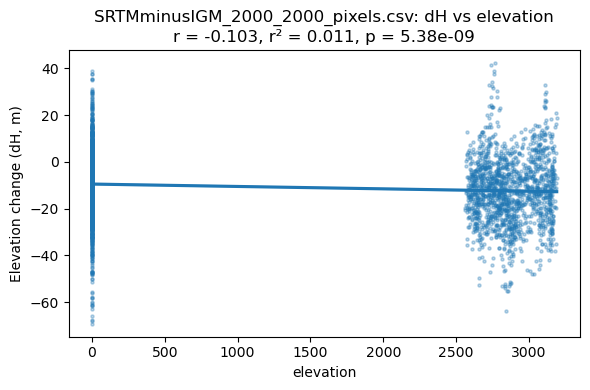

dH vs slope | r = -0.051, r² = 0.003, p = 0.00397


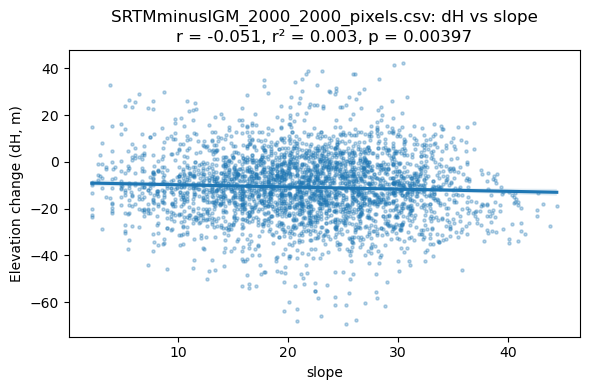

dH vs aspect | r = -0.004, r² = 0.000, p = 0.817


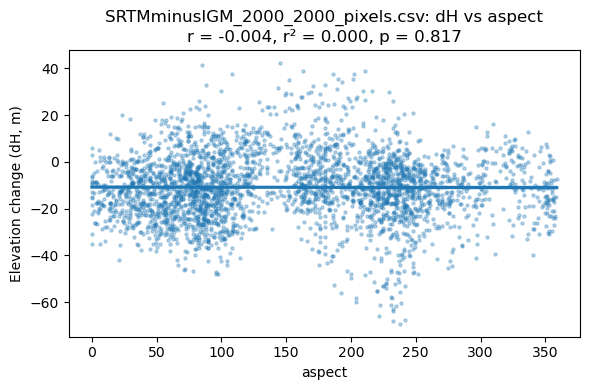

Skipping SRTMminusIGM_2019_2000_pixels.csv because years do not match or are ambiguous: ['2019', '2000']

Processing SRTMminusIGM_2019_2019_pixels.csv for year 2019
dH pixels: 2119, elev: 6467, slope: 6467, aspect: 6467
dH vs elevation | r = 0.125, r² = 0.016, p = 8.51e-09


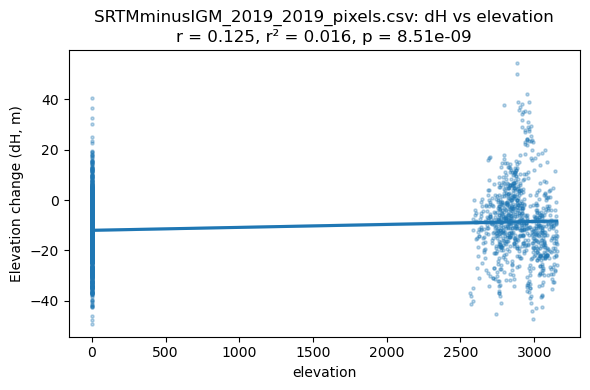

dH vs slope | r = 0.018, r² = 0.000, p = 0.416


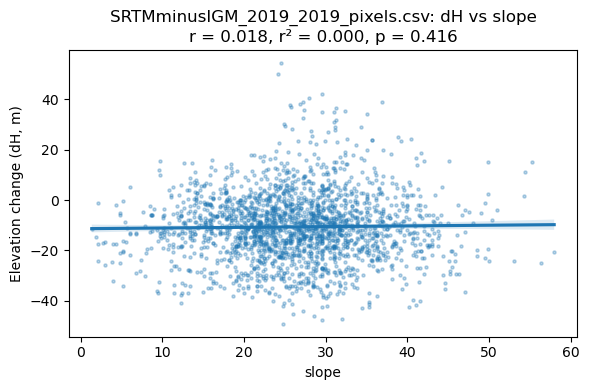

dH vs aspect | r = -0.024, r² = 0.001, p = 0.265


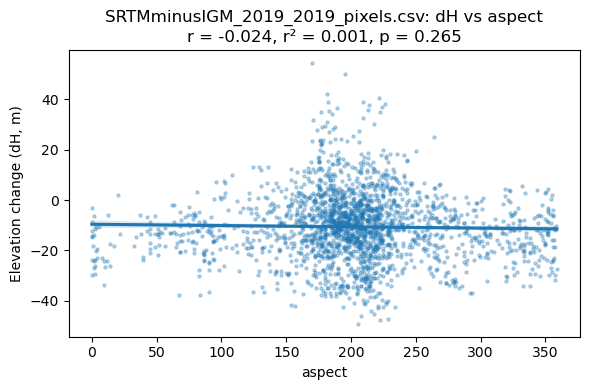


Processing LTminusIGM_2000_2000_pixels.csv for year 2000
dH pixels: 649, elev: 8311, slope: 8311, aspect: 8311
dH vs elevation | r = 0.008, r² = 0.000, p = 0.842


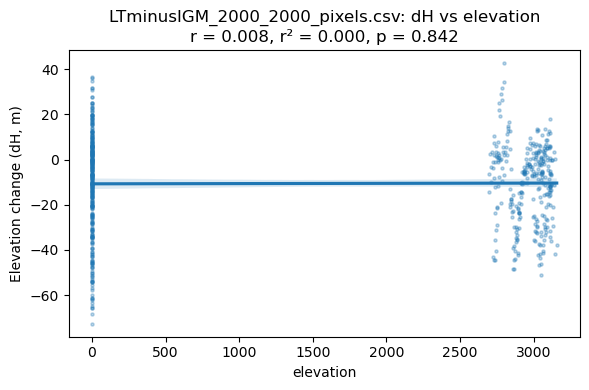

dH vs slope | r = -0.070, r² = 0.005, p = 0.0752


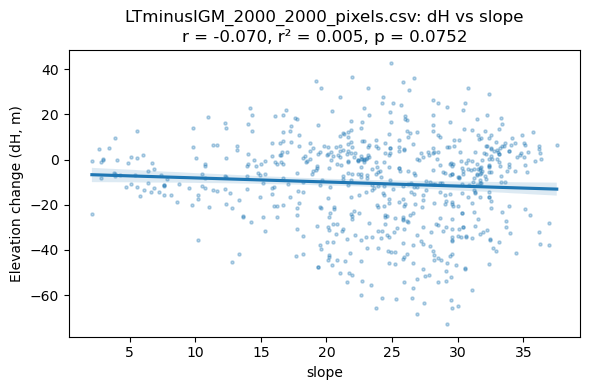

dH vs aspect | r = -0.103, r² = 0.011, p = 0.00892


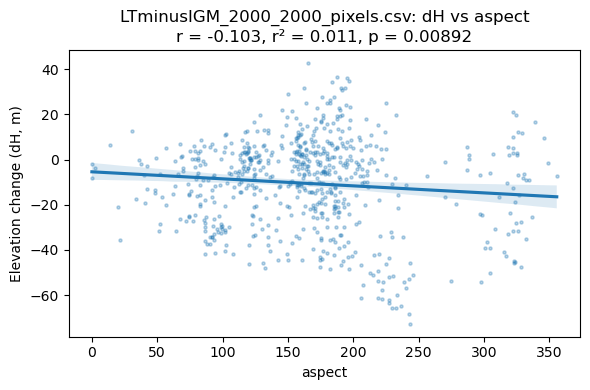


Processing LTminusIGM_2019_2019_pixels.csv for year 2019
dH pixels: 460, elev: 6467, slope: 6467, aspect: 6467
dH vs elevation | r = 0.046, r² = 0.002, p = 0.327


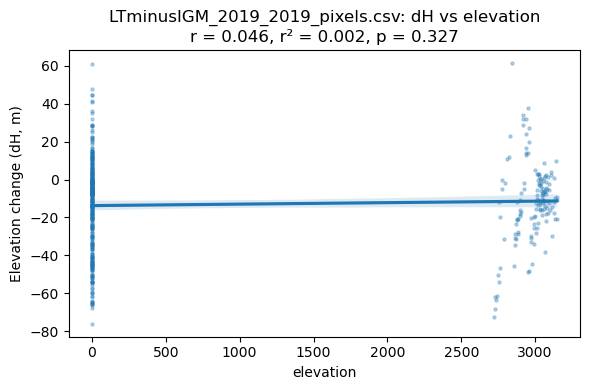

dH vs slope | r = 0.054, r² = 0.003, p = 0.25


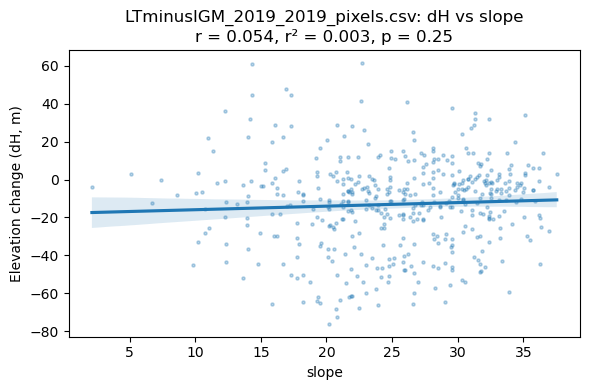

dH vs aspect | r = 0.225, r² = 0.051, p = 1.12e-06


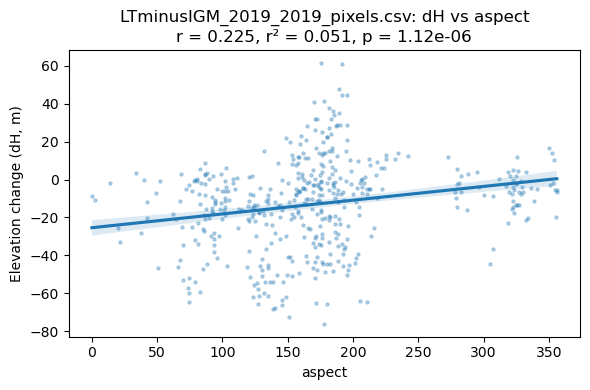

Skipping t_test_results.csv because years do not match or are ambiguous: []

Processing CBminusSRTM_2019_2019_pixels.csv for year 2019
dH pixels: 656, elev: 6467, slope: 6467, aspect: 6467
dH vs elevation | r = 0.175, r² = 0.031, p = 6.52e-06


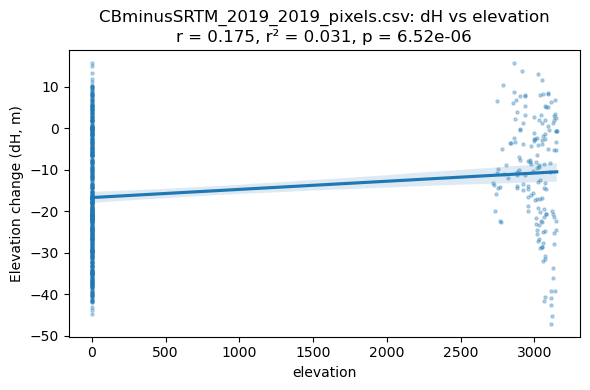

dH vs slope | r = 0.097, r² = 0.009, p = 0.0128


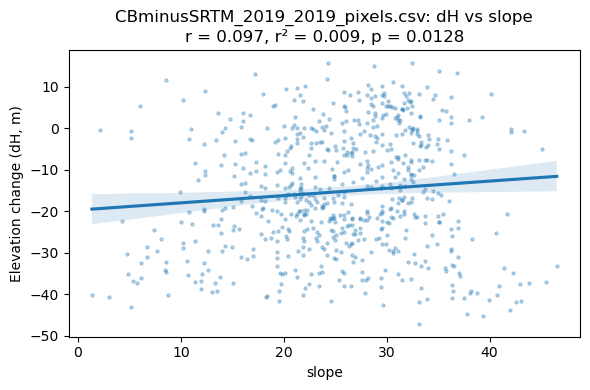

dH vs aspect | r = -0.084, r² = 0.007, p = 0.0317


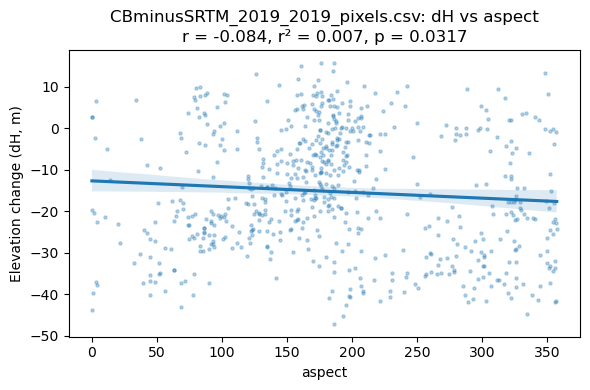

Skipping t_test_results_2000_vs_2019.csv because years do not match or are ambiguous: ['2000']

Processing CBminusSRTM_2000_2000_pixels.csv for year 2000
dH pixels: 764, elev: 8311, slope: 8311, aspect: 8311
dH vs elevation | r = 0.049, r² = 0.002, p = 0.177


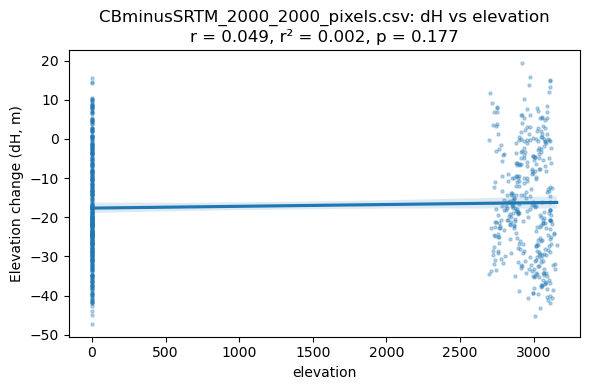

dH vs slope | r = 0.146, r² = 0.021, p = 4.98e-05


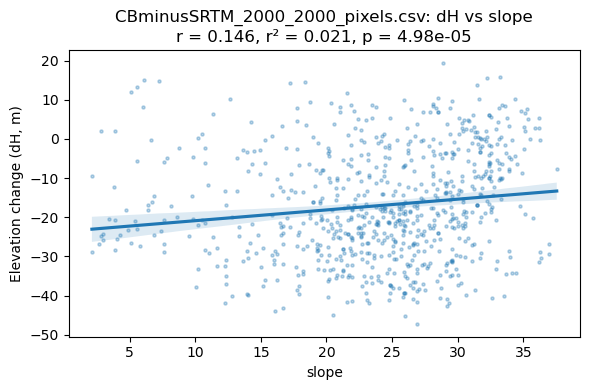

dH vs aspect | r = -0.088, r² = 0.008, p = 0.0146


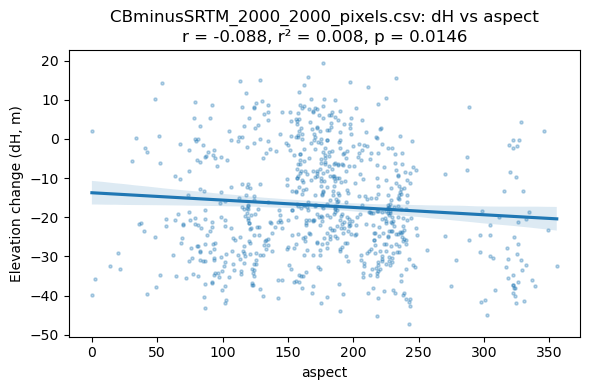


Processing CBminusIGM_2019_2019_pixels.csv for year 2019
dH pixels: 656, elev: 6467, slope: 6467, aspect: 6467
dH vs elevation | r = 0.155, r² = 0.024, p = 6.42e-05


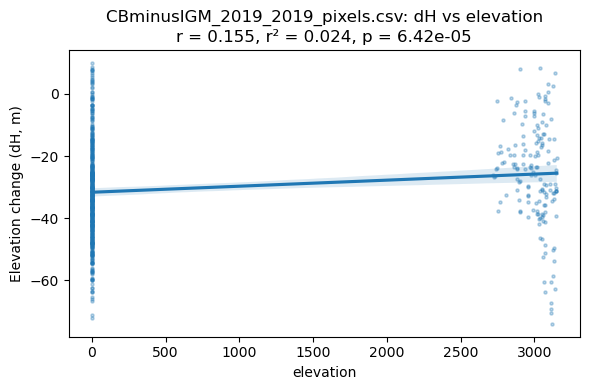

dH vs slope | r = 0.075, r² = 0.006, p = 0.0559


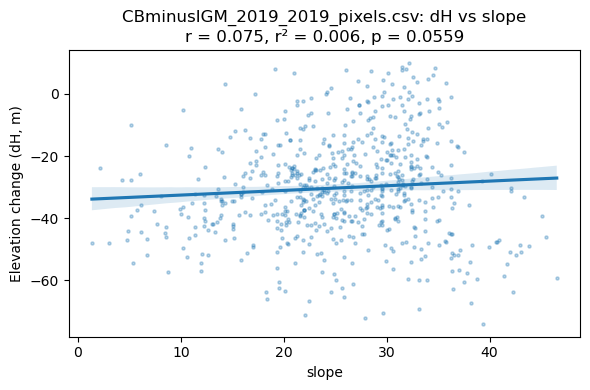

dH vs aspect | r = -0.200, r² = 0.040, p = 2.48e-07


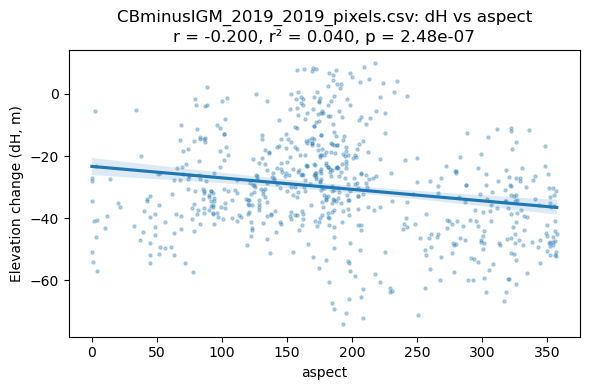

Skipping All_dH_pixels_combined.csv because years do not match or are ambiguous: []

Processing LTminusSRTM_2000_2000_pixels.csv for year 2000
dH pixels: 649, elev: 8311, slope: 8311, aspect: 8311
dH vs elevation | r = 0.230, r² = 0.053, p = 2.93e-09


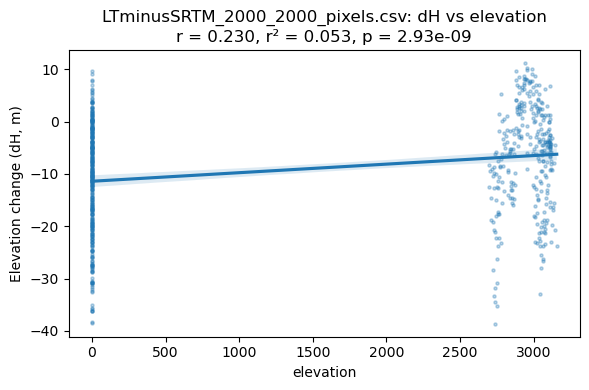

dH vs slope | r = 0.189, r² = 0.036, p = 1.21e-06


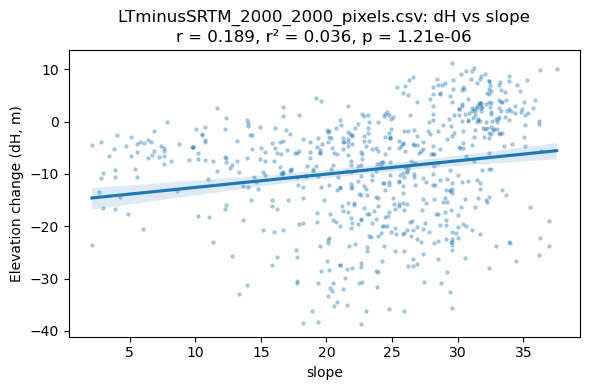

dH vs aspect | r = -0.043, r² = 0.002, p = 0.271


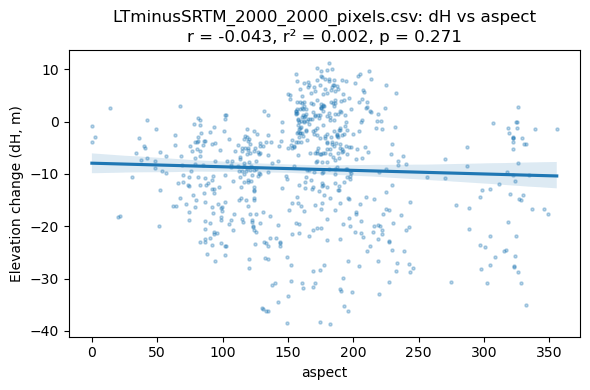


Processing LTminusSRTM_2019_2019_pixels.csv for year 2019
dH pixels: 460, elev: 6467, slope: 6467, aspect: 6467
dH vs elevation | r = 0.032, r² = 0.001, p = 0.499


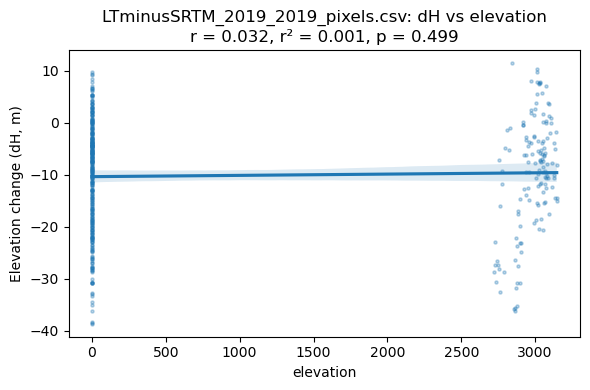

dH vs slope | r = 0.247, r² = 0.061, p = 8.44e-08


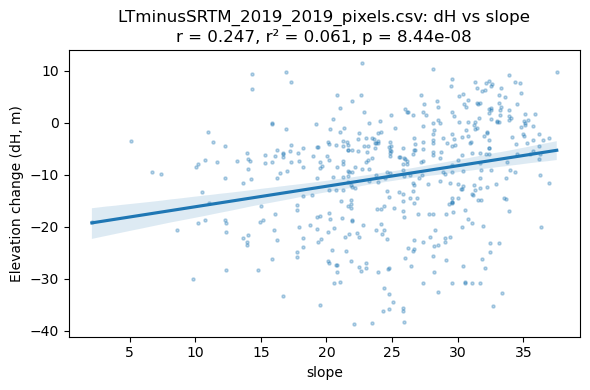

dH vs aspect | r = 0.173, r² = 0.030, p = 0.000194


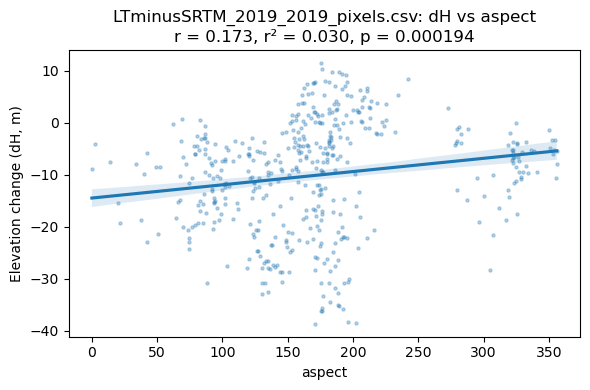


Processing CBminusIGM_2000_2000_pixels.csv for year 2000
dH pixels: 764, elev: 8311, slope: 8311, aspect: 8311
dH vs elevation | r = 0.104, r² = 0.011, p = 0.00394


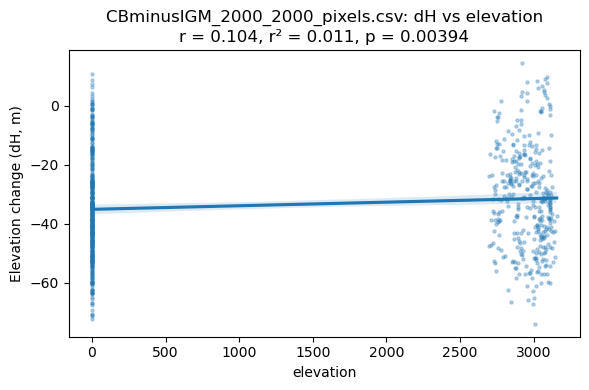

dH vs slope | r = 0.154, r² = 0.024, p = 1.83e-05


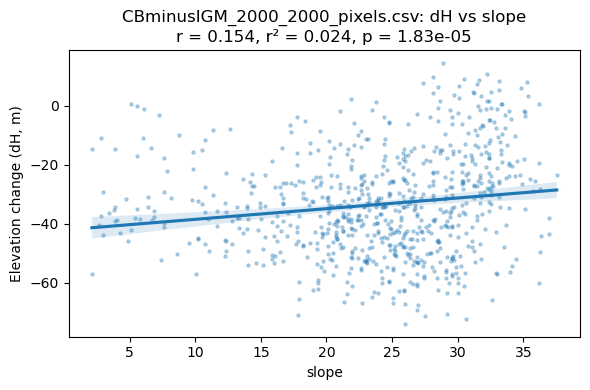

dH vs aspect | r = -0.165, r² = 0.027, p = 4.37e-06


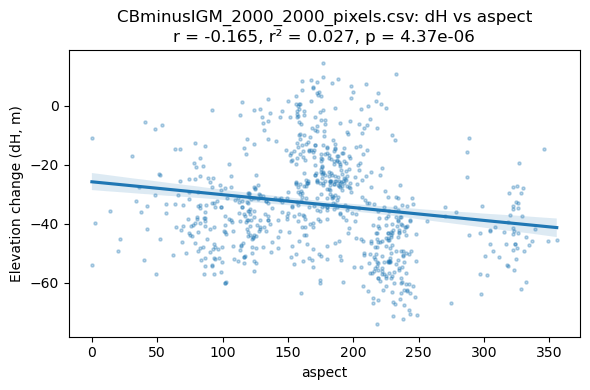

In [45]:
import os
import pandas as pd
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import geopandas as gpd
from rasterio.mask import mask

# Folder where Step 1 saved dH CSV files
dH_csv_folder = "/Users/milliespencer/Desktop/70_Years_MB_Nevados/Nevados_dH_Stats/pixel_stats"

# Path to the true elevation DEM raster (SRTM)
dem_path = "/Users/milliespencer/Desktop/70_Years_MB_Nevados/NEWDEMs_to_coregister_nevados/SRTM_DEMprojected.tif"

# Paths to glacier shapefiles by year
glacier_shapefiles = {
    "2000": "/Users/milliespencer/Glacier-DEM-coregistration-and-MB/example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2000/Nevados_polygons_DGA2000.shp",
    "2019": "/Users/milliespencer/Glacier-DEM-coregistration-and-MB/example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2019/Nevados_polygons_DGA2019.shp"
}

def calculate_slope_aspect(dem_array, dem_transform):
    xres = dem_transform[0]
    yres = -dem_transform[4]

    dy, dx = np.gradient(dem_array, yres, xres)
    slope_rad = np.arctan(np.sqrt(dx**2 + dy**2))
    slope_deg = np.degrees(slope_rad)

    aspect_rad = np.arctan2(-dx, dy)
    aspect_deg = np.degrees(aspect_rad)
    aspect_deg = np.where(aspect_deg < 0, 360 + aspect_deg, aspect_deg)

    return slope_deg, aspect_deg

print("Loading DEM and calculating slope/aspect...")
with rasterio.open(dem_path) as dem_src:
    dem_arr = dem_src.read(1)
    dem_arr = np.where((dem_arr >= 1e38) | (dem_arr <= -9999), np.nan, dem_arr)
    dem_transform = dem_src.transform
    slope_arr, aspect_arr = calculate_slope_aspect(dem_arr, dem_transform)
print("Done with DEM preprocessing.")

# Loop over each dH CSV file from Step 1
for filename in os.listdir(dH_csv_folder):
    if not filename.endswith(".csv"):
        continue

    parts = filename.split('_')
    years_in_name = [p for p in parts if p in ["2000", "2019"]]

    if len(years_in_name) != 2 or years_in_name[0] != years_in_name[1]:
        print(f"Skipping {filename} because years do not match or are ambiguous: {years_in_name}")
        continue

    year = years_in_name[0]
    print(f"\nProcessing {filename} for year {year}")

    # Load glacier polygons for this year
    gdf = gpd.read_file(glacier_shapefiles[year])

    # Load dH values
    dH_df = pd.read_csv(os.path.join(dH_csv_folder, filename))
    dH_values = dH_df['dh'].values

    all_dem_elev = []
    all_dem_slope = []
    all_dem_aspect = []

    with rasterio.open(dem_path) as dem_src:
        for _, row in gdf.iterrows():
            if row.geometry is None or row.geometry.is_empty:
                continue
            try:
                window_image, window_transform = mask(dem_src, [row.geometry], crop=True)
                window_elev = window_image[0]
                window_elev = np.where((window_elev >= 1e38) | (window_elev <= -9999), np.nan, window_elev)

                rows, cols = np.where(~np.isnan(window_elev))

                global_rows = rows + int((window_transform.f - dem_transform.f) / dem_transform.e)
                global_cols = cols + int((window_transform.c - dem_transform.c) / dem_transform.a)

                elev_vals = window_elev[rows, cols]
                slope_vals = slope_arr[global_rows, global_cols]
                aspect_vals = aspect_arr[global_rows, global_cols]

                all_dem_elev.extend(elev_vals)
                all_dem_slope.extend(slope_vals)
                all_dem_aspect.extend(aspect_vals)

            except Exception as e:
                print(f"Error processing polygon: {e}")
                continue

    all_dem_elev = np.array(all_dem_elev)
    all_dem_slope = np.array(all_dem_slope)
    all_dem_aspect = np.array(all_dem_aspect)

    print(f"dH pixels: {len(dH_values)}, elev: {len(all_dem_elev)}, slope: {len(all_dem_slope)}, aspect: {len(all_dem_aspect)}")
    min_len = min(len(dH_values), len(all_dem_elev), len(all_dem_slope), len(all_dem_aspect))

    if min_len == 0:
        print(f"No valid combined data for {filename}, skipping.")
        continue

    dH_values = dH_values[:min_len]
    all_dem_elev = all_dem_elev[:min_len]
    all_dem_slope = all_dem_slope[:min_len]
    all_dem_aspect = all_dem_aspect[:min_len]

    df = pd.DataFrame({
        'dH': dH_values,
        'elevation': all_dem_elev,
        'slope': all_dem_slope,
        'aspect': all_dem_aspect
    }).dropna()

    if df.empty:
        print(f"No valid data after dropping NaNs for {filename}, skipping.")
        continue

    for var in ['elevation', 'slope', 'aspect']:
        r, p = pearsonr(df['dH'], df[var])
        r2 = r ** 2
        print(f"dH vs {var} | r = {r:.3f}, r² = {r2:.3f}, p = {p:.3g}")

        plt.figure(figsize=(6, 4))
        sns.regplot(x=var, y='dH', data=df, scatter_kws={'alpha': 0.3, 's': 5})
        plt.title(f"{filename}: dH vs {var}\nr = {r:.3f}, r² = {r2:.3f}, p = {p:.3g}")
        plt.xlabel(var)
        plt.ylabel("Elevation change (dH, m)")
        plt.tight_layout()
        plt.show()

# Now looking at monthly, seasonal, and annual changes in station precip data


--- Diguillin ---


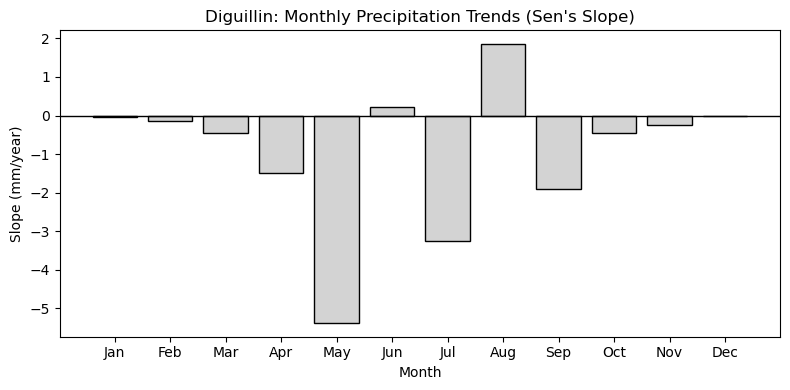


Month trends for Diguillin:
    month     slope   p_value  significant
0       1 -0.051316  0.660361        False
1       2 -0.149074  0.596873        False
2       3 -0.464103  0.285754        False
3       4 -1.494907  0.212491        False
4       5 -5.375000  0.082563        False
5       6  0.220982  0.916487        False
6       7 -3.250000  0.230974        False
7       8  1.847368  0.345109        False
8       9 -1.909091  0.156799        False
9      10 -0.454545  0.753201        False
10     11 -0.235294  0.820917        False
11     12  0.000000  0.925504        False


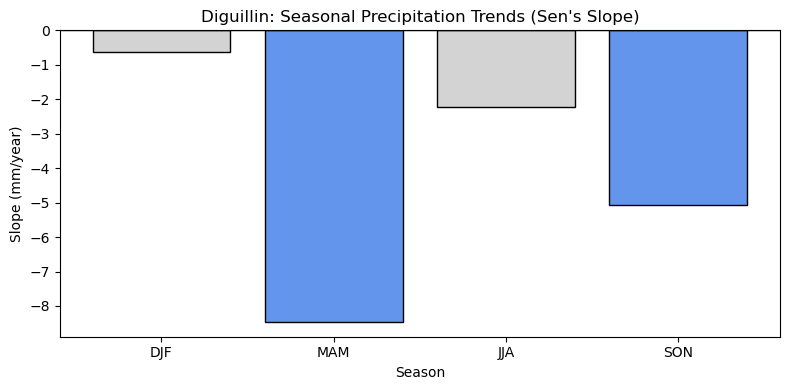


Season trends for Diguillin:
           slope   p_value  significant
season                                 
DJF    -0.641711  0.393222        False
MAM    -8.468750  0.009780         True
JJA    -2.238095  0.616375        False
SON    -5.077857  0.039159         True
Annual trend: Sen's slope = -22.20 mm/year, p = 0.009, significant = True

--- Las Trancas ---


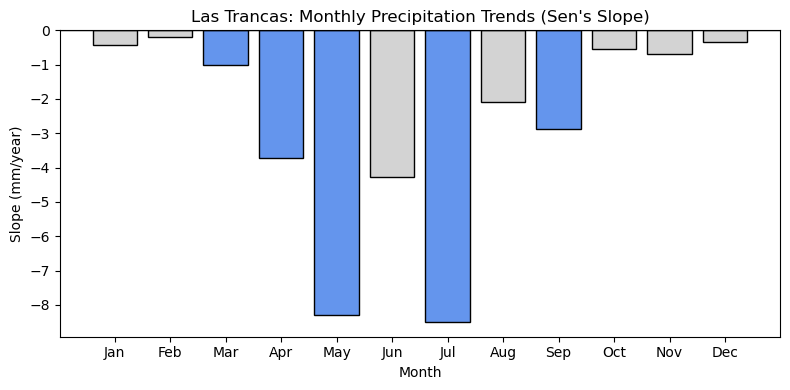


Month trends for Las Trancas:
    month     slope   p_value  significant
0       1 -0.414216  0.147189        False
1       2 -0.193750  0.381262        False
2       3 -1.000000  0.045255         True
3       4 -3.717105  0.019878         True
4       5 -8.300000  0.010017         True
5       6 -4.272727  0.222627        False
6       7 -8.500000  0.009471         True
7       8 -2.086957  0.352129        False
8       9 -2.866667  0.033083         True
9      10 -0.535714  0.637669        False
10     11 -0.679487  0.339452        False
11     12 -0.333333  0.418562        False


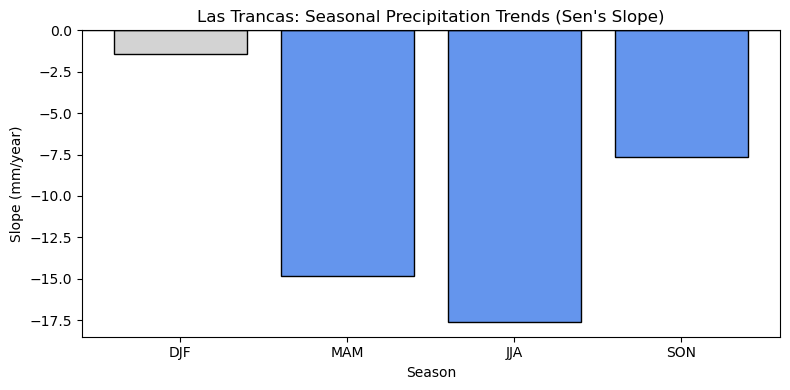


Season trends for Las Trancas:
            slope   p_value  significant
season                                  
DJF     -1.401515  0.156977        False
MAM    -14.849624  0.000024         True
JJA    -17.615385  0.001660         True
SON     -7.633333  0.010783         True
Annual trend: Sen's slope = -48.86 mm/year, p = 0.000, significant = True


In [19]:
# ==========================================================
# Trend Analysis using Sen's Slope (no OLS regression)
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk

# ------------------- FILE PATHS -------------------
stations = {
    "Diguillin": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Diguillin_codigo[C08130006].csv",
    "Las Trancas": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Las Trancas_codigo[C08130004].csv"
}

date_column = 'date'

# ------------------- FUNCTIONS -------------------

def load_data(filepath):
    """Load CSV and parse dates, removing missing values (-9999)."""
    df = pd.read_csv(filepath)
    df[date_column] = pd.to_datetime(df.iloc[:, 0], errors='coerce')
    df['precip'] = df.iloc[:, 1].replace(-9999, np.nan)
    df = df.dropna(subset=['precip', date_column])
    return df

def assign_season(df):
    """Assign season and year to each row."""
    df["month"] = df[date_column].dt.month
    df["year"] = df[date_column].dt.year
    df["season"] = df["month"].map({
        12:"DJF", 1:"DJF", 2:"DJF",
        3:"MAM", 4:"MAM", 5:"MAM",
        6:"JJA", 7:"JJA", 8:"JJA",
        9:"SON", 10:"SON", 11:"SON"
    })
    return df

def compute_sens_slope(series):
    """
    Compute Sen's slope and Mann–Kendall significance test.
    Returns slope (mm/year) and p-value.
    """
    valid = series.dropna()
    if len(valid) <= 10:
        return np.nan, np.nan, False
    result = mk.original_test(valid.values)
    return result.slope, result.p, result.p < 0.05

def compute_monthly_trends(df):
    """Compute Sen's slope trend for each month."""
    trends = []
    for month in range(1, 13):
        series = df[df['month'] == month].groupby('year')['precip'].sum()
        slope, p_value, sig = compute_sens_slope(series)
        trends.append({
            "month": month,
            "slope": slope,
            "p_value": p_value,
            "significant": sig
        })
    return pd.DataFrame(trends)

def compute_seasonal_trends(df):
    """Compute Sen's slope trend for each season."""
    trends = []
    for season in ["DJF", "MAM", "JJA", "SON"]:
        series = df[df['season'] == season].groupby('year')['precip'].sum()
        slope, p_value, sig = compute_sens_slope(series)
        trends.append({
            "season": season,
            "slope": slope,
            "p_value": p_value,
            "significant": sig
        })
    return pd.DataFrame(trends).set_index("season")

def compute_annual_trend(df):
    """Compute Sen's slope trend for total annual precipitation."""
    series = df.groupby('year')['precip'].sum()
    slope, p_value, sig = compute_sens_slope(series)
    if not np.isnan(slope):
        print(f"Annual trend: Sen's slope = {slope:.2f} mm/year, p = {p_value:.3f}, significant = {sig}")
    else:
        print("Annual trend: insufficient data")

def plot_trends(df_trends, label, timescale):
    """Plot monthly or seasonal Sen's slope trends."""
    fig, ax = plt.subplots(figsize=(8,4))
    colors = ['cornflowerblue' if sig else 'lightgray' for sig in df_trends['significant']]

    if timescale == "month":
        x = df_trends["month"]
        ax.set_xticks(range(1,13))
        ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
        ax.set_xlabel("Month")
        ax.set_title(f"{label}: Monthly Precipitation Trends (Sen's Slope)")
    else:
        x = df_trends.index
        ax.set_xlabel("Season")
        ax.set_title(f"{label}: Seasonal Precipitation Trends (Sen's Slope)")

    y = df_trends["slope"]
    ax.bar(x, y, color=colors, edgecolor='k')
    ax.axhline(0, color='k', linewidth=1)
    ax.set_ylabel("Slope (mm/year)")
    plt.tight_layout()
    plt.show()

    print(f"\n{timescale.capitalize()} trends for {label}:")
    print(df_trends)

# ------------------- RUN ANALYSIS -------------------

for station, path in stations.items():
    print(f"\n--- {station} ---")
    df = load_data(path)
    df = assign_season(df)

    # Monthly
    monthly_trends = compute_monthly_trends(df)
    plot_trends(monthly_trends, station, "month")

    # Seasonal
    seasonal_trends = compute_seasonal_trends(df)
    plot_trends(seasonal_trends, station, "season")

    # Annual
    compute_annual_trend(df)


## Now for temperature data: 


--- Diguillin ---


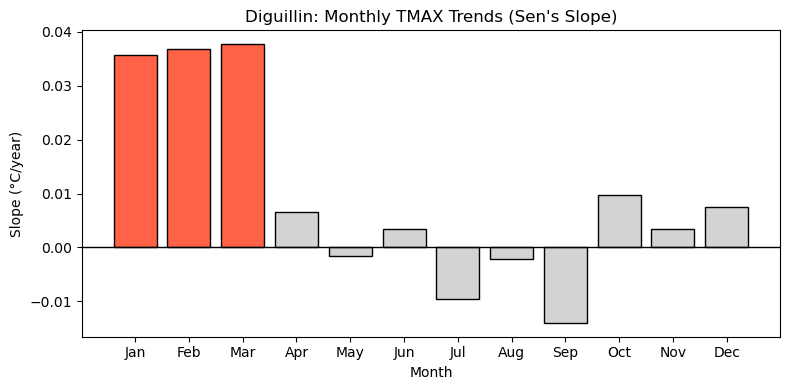


Month trends for Diguillin - TMAX:
    month     slope   p_value  significant
0       1  0.035670  0.018692         True
1       2  0.036779  0.026596         True
2       3  0.037702  0.011303         True
3       4  0.006545  0.710726        False
4       5 -0.001654  0.905778        False
5       6  0.003450  0.752266        False
6       7 -0.009570  0.542401        False
7       8 -0.002194  0.818992        False
8       9 -0.013978  0.262314        False
9      10  0.009759  0.553964        False
10     11  0.003375  0.868383        False
11     12  0.007589  0.619092        False


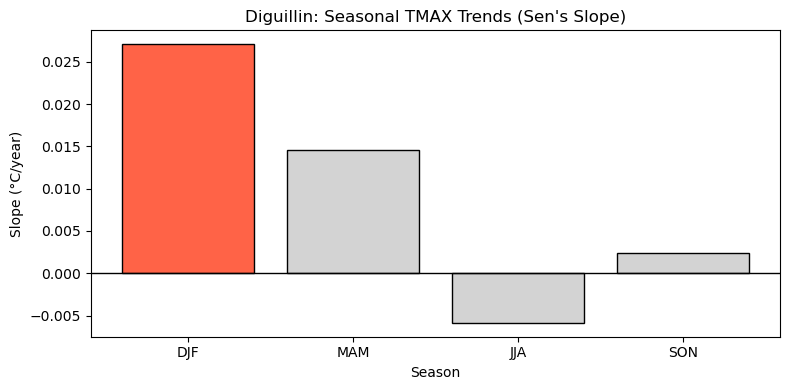


Season trends for Diguillin - TMAX:
           slope   p_value  significant
season                                 
DJF     0.027063  0.016094         True
MAM     0.014621  0.127764        False
JJA    -0.005854  0.652861        False
SON     0.002366  0.770310        False
Annual trend for tmax: Sen's slope = 0.010 °C/year, p = 0.204, significant = False


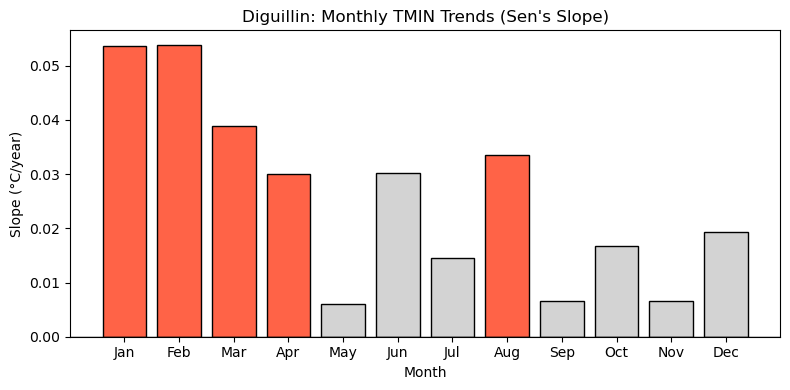


Month trends for Diguillin - TMIN:
    month     slope   p_value  significant
0       1  0.053560  0.000030         True
1       2  0.053816  0.000085         True
2       3  0.038793  0.011308         True
3       4  0.030020  0.017914         True
4       5  0.005946  0.647170        False
5       6  0.030136  0.073249        False
6       7  0.014516  0.159965        False
7       8  0.033427  0.002930         True
8       9  0.006667  0.450015        False
9      10  0.016640  0.157802        False
10     11  0.006574  0.641521        False
11     12  0.019355  0.121936        False


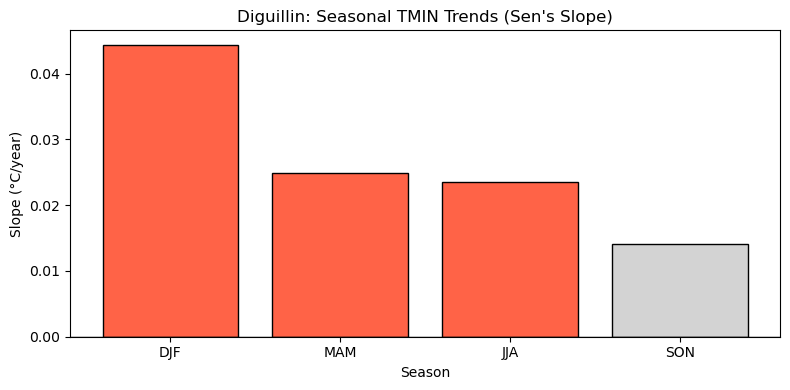


Season trends for Diguillin - TMIN:
           slope   p_value  significant
season                                 
DJF     0.044367  0.000015         True
MAM     0.024876  0.018303         True
JJA     0.023552  0.002033         True
SON     0.014105  0.172204        False
Annual trend for tmin: Sen's slope = 0.029 °C/year, p = 0.000, significant = True


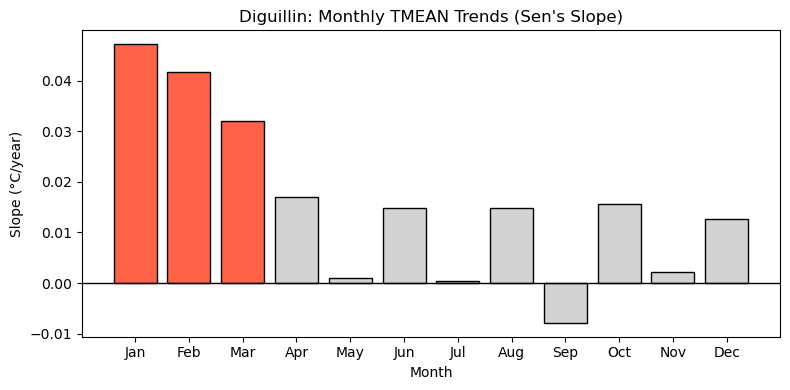


Month trends for Diguillin - TMEAN:
    month     slope   p_value  significant
0       1  0.047178  0.000030         True
1       2  0.041708  0.000598         True
2       3  0.032031  0.002033         True
3       4  0.016952  0.127764        False
4       5  0.001003  0.943382        False
5       6  0.014781  0.127764        False
6       7  0.000330  0.974082        False
7       8  0.014890  0.162498        False
8       9 -0.007857  0.426046        False
9      10  0.015703  0.246054        False
10     11  0.002222  0.868383        False
11     12  0.012568  0.444013        False


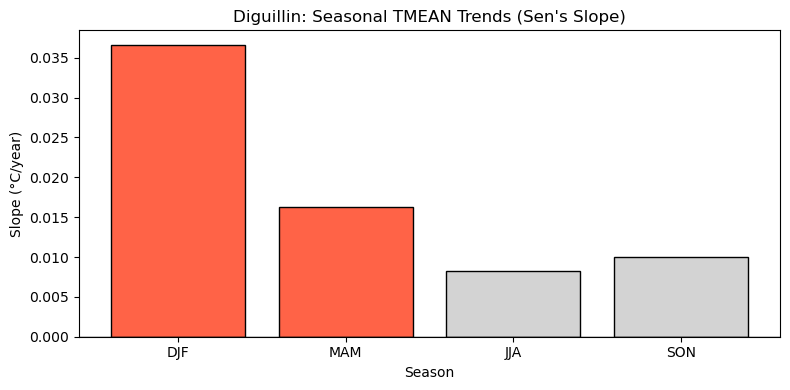


Season trends for Diguillin - TMEAN:
           slope   p_value  significant
season                                 
DJF     0.036606  0.000021         True
MAM     0.016238  0.026596         True
JJA     0.008302  0.381079        False
SON     0.010003  0.187567        False
Annual trend for tmean: Sen's slope = 0.024 °C/year, p = 0.000, significant = True


In [20]:
# ==========================================================
# Temperature Trend Analysis using Sen's Slope (no OLS regression)
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk

# ------------------- FILE PATHS -------------------
station_files = {
    "Diguillin": {
        "tmax": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/temp_max_diguillin.csv",
        "tmin": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/temp_min_diguillin.csv"
    }
}

date_column = 'date'

# ------------------- FUNCTIONS -------------------

def load_temp(filepath):
    """Load temperature CSV and compute monthly mean values."""
    df = pd.read_csv(filepath)
    
    # Clean up column names (remove spaces, lowercase)
    df.columns = df.columns.str.strip().str.lower()
    # Expected columns: 'agno', 'mes', 'dia', 'valor'
    
    # Build proper datetime column
    df[date_column] = pd.to_datetime(
        df[['agno','mes','dia']].astype(str).agg('-'.join, axis=1), errors='coerce'
    )
    
    # Replace missing values (-9999) and drop NA
    df['valor'] = df['valor'].replace(-9999, np.nan)
    df = df.dropna(subset=['valor', date_column])
    
    # Aggregate to monthly mean
    df['year_month'] = df[date_column].dt.to_period('M')
    df_monthly = df.groupby('year_month')['valor'].mean().reset_index()
    df_monthly[date_column] = df_monthly['year_month'].dt.to_timestamp()
    
    return df_monthly.rename(columns={'valor': 'temp'})

def merge_temps(tmax_file, tmin_file):
    """Merge Tmax and Tmin to compute Tmean."""
    tmax = load_temp(tmax_file).rename(columns={'temp': 'tmax'})
    tmin = load_temp(tmin_file).rename(columns={'temp': 'tmin'})
    df = pd.merge(tmax, tmin, on=date_column, how='inner')
    df['tmean'] = (df['tmax'] + df['tmin']) / 2
    return df

def assign_season(df):
    """Assign season and year to each row."""
    df["month"] = df[date_column].dt.month
    df["year"] = df[date_column].dt.year
    df["season"] = df["month"].map({
        12:"DJF", 1:"DJF", 2:"DJF",
        3:"MAM", 4:"MAM", 5:"MAM",
        6:"JJA", 7:"JJA", 8:"JJA",
        9:"SON", 10:"SON", 11:"SON"
    })
    return df

# ------------------- SEN'S SLOPE CORE FUNCTION -------------------

def compute_sens_slope(series):
    """
    Compute Sen's slope and Mann–Kendall significance test.
    Returns slope (°C/year), p-value, and significance flag.
    """
    valid = series.dropna()
    if len(valid) <= 10:
        return np.nan, np.nan, False
    result = mk.original_test(valid.values)
    return result.slope, result.p, result.p < 0.05

# ------------------- TREND COMPUTATION FUNCTIONS -------------------

def compute_monthly_trends(df, var):
    """Compute Sen's slope trend for each month."""
    trends = []
    for month in range(1, 13):
        series = df[df['month'] == month].groupby('year')[var].mean()
        slope, p_value, sig = compute_sens_slope(series)
        trends.append({
            "month": month,
            "slope": slope,
            "p_value": p_value,
            "significant": sig
        })
    return pd.DataFrame(trends)

def compute_seasonal_trends(df, var):
    """Compute Sen's slope trend for each season."""
    trends = []
    for season in ["DJF", "MAM", "JJA", "SON"]:
        series = df[df['season'] == season].groupby('year')[var].mean()
        slope, p_value, sig = compute_sens_slope(series)
        trends.append({
            "season": season,
            "slope": slope,
            "p_value": p_value,
            "significant": sig
        })
    return pd.DataFrame(trends).set_index("season")

def compute_annual_trend(df, var):
    """Compute Sen's slope trend for total annual temperature mean."""
    series = df.groupby('year')[var].mean()
    slope, p_value, sig = compute_sens_slope(series)
    if not np.isnan(slope):
        print(f"Annual trend for {var}: Sen's slope = {slope:.3f} °C/year, p = {p_value:.3f}, significant = {sig}")
    else:
        print(f"Annual trend for {var}: insufficient data")

# ------------------- PLOTTING -------------------

def plot_trends(df_trends, label, timescale, var):
    """Plot monthly or seasonal Sen's slope trends."""
    fig, ax = plt.subplots(figsize=(8, 4))
    colors = ['tomato' if sig else 'lightgray' for sig in df_trends['significant']]
    
    if timescale == "month":
        x = df_trends["month"]
        ax.set_xticks(range(1, 13))
        ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
        ax.set_xlabel("Month")
        ax.set_title(f"{label}: Monthly {var.upper()} Trends (Sen's Slope)")
    else:
        x = df_trends.index
        ax.set_xlabel("Season")
        ax.set_title(f"{label}: Seasonal {var.upper()} Trends (Sen's Slope)")
    
    y = df_trends["slope"]
    ax.bar(x, y, color=colors, edgecolor='k')
    ax.axhline(0, color='k', linewidth=1)
    ax.set_ylabel("Slope (°C/year)")
    plt.tight_layout()
    plt.show()
    
    print(f"\n{timescale.capitalize()} trends for {label} - {var.upper()}:")
    print(df_trends)

# ------------------- RUN ANALYSIS -------------------

for station, files in station_files.items():
    print(f"\n--- {station} ---")
    df = merge_temps(files["tmax"], files["tmin"])
    df = assign_season(df)
    
    for var in ["tmax", "tmin", "tmean"]:
        # Monthly
        monthly_trends = compute_monthly_trends(df, var)
        plot_trends(monthly_trends, station, "month", var)
        
        # Seasonal
        seasonal_trends = compute_seasonal_trends(df, var)
        plot_trends(seasonal_trends, station, "season", var)
        
        # Annual
        compute_annual_trend(df, var)


## Decadal analysis 


--- Decadal Precip Means for Diguillin ---
decade
1980s    183.741667
1990s    168.708333
2000s    195.300000
2010s    140.254717
Name: precip, dtype: float64


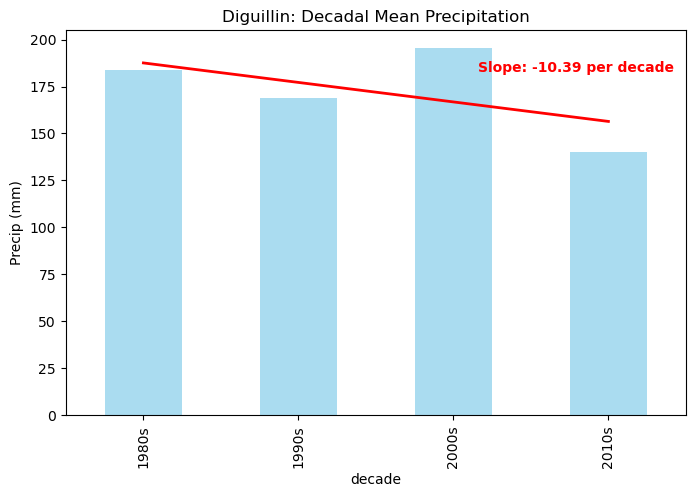


--- Decadal Temp Means for Diguillin ---
decade
1980s    11.887372
1990s    12.112246
2000s    12.184738
2010s    12.201495
Name: tmean, dtype: float64


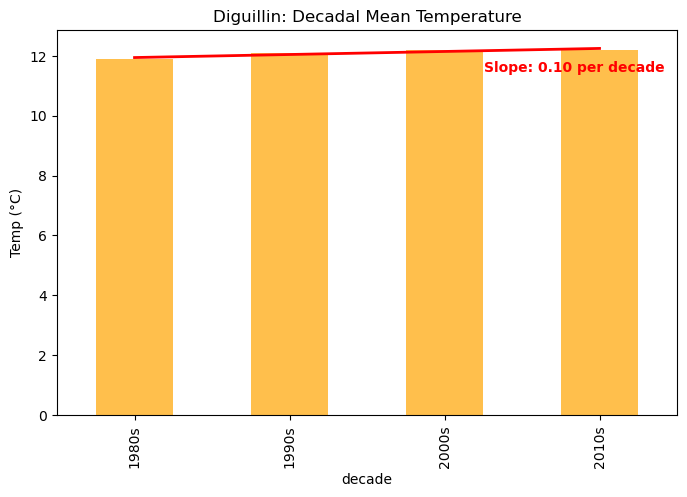


--- Decadal Precip Means for Las Trancas ---
decade
1980s    206.728070
1990s    176.940678
2000s    180.356522
2010s     97.010309
Name: precip, dtype: float64


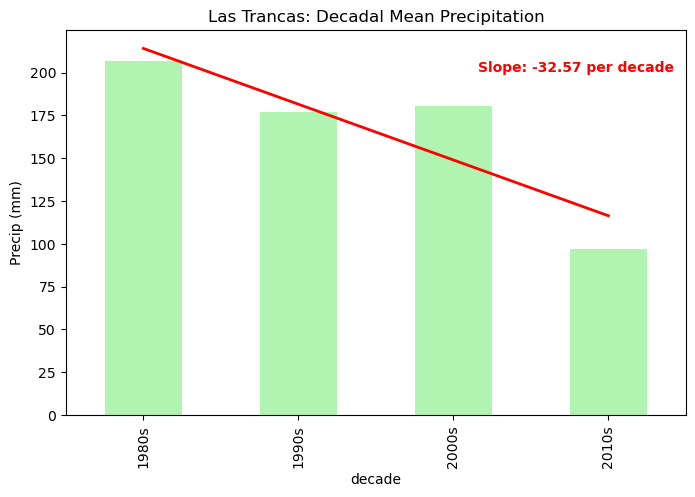

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

date_column = "date"

# ------------------- FILE PATHS -------------------
station_files = {
    "Diguillin": {
        "precip": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Diguillin_codigo[C08130006].csv",
        "tmax": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/temp_max_diguillin.csv",
        "tmin": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/temp_min_diguillin.csv"
    },
    "Las Trancas": {
        "precip": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Las Trancas_codigo[C08130004].csv"
    }
}

# ------------------- FUNCTIONS -------------------

def load_precip(filepath):
    df = pd.read_csv(filepath)
    df[date_column] = pd.to_datetime(df.iloc[:, 0], errors="coerce")
    df["precip"] = df.iloc[:, 1].replace(-9999, np.nan)
    df = df.dropna(subset=["precip", date_column])
    df["year"] = df[date_column].dt.year
    return df

def load_temp(filepath):
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip().str.lower()  # clean headers
    df[date_column] = pd.to_datetime(
        df[["agno","mes","dia"]].astype(str).agg("-".join, axis=1), errors="coerce"
    )
    df["valor"] = df["valor"].replace(-9999, np.nan)
    df = df.dropna(subset=["valor", date_column])
    df["year_month"] = df[date_column].dt.to_period("M")
    df_monthly = df.groupby("year_month")["valor"].mean().reset_index()
    df_monthly[date_column] = df_monthly["year_month"].dt.to_timestamp()
    return df_monthly.rename(columns={"valor":"temp"})

def assign_decade(year):
    if 1980 <= year < 1990:
        return "1980s"
    elif 1990 <= year < 2000:
        return "1990s"
    elif 2000 <= year < 2010:
        return "2000s"
    elif 2010 <= year < 2020:
        return "2010s"
    else:
        return np.nan

def compute_decadal_means_precip(df_precip, label):
    df_precip["decade"] = df_precip["year"].apply(assign_decade)
    decadal_precip = df_precip.groupby("decade")["precip"].mean()
    print(f"\n--- Decadal Precip Means for {label} ---")
    print(decadal_precip)
    return decadal_precip

def compute_decadal_means_temp(df_tmax, df_tmin, label):
    df_tmean = pd.merge(df_tmax, df_tmin, on=[date_column,"year_month"], suffixes=("_tmax","_tmin"))
    df_tmean["tmean"] = (df_tmean["temp_tmax"] + df_tmean["temp_tmin"])/2
    df_tmean["year"] = df_tmean[date_column].dt.year
    df_tmean["decade"] = df_tmean["year"].apply(assign_decade)
    decadal_temp = df_tmean.groupby("decade")["tmean"].mean()
    print(f"\n--- Decadal Temp Means for {label} ---")
    print(decadal_temp)
    return decadal_temp

def plot_decadal_bar(decadal_series, ylabel, title, color="skyblue"):
    fig, ax = plt.subplots(figsize=(8,5))
    decadal_series.plot(kind="bar", color=color, alpha=0.7, ax=ax)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    # Add trendline
    x = np.arange(len(decadal_series))
    y = decadal_series.values
    slope, intercept = np.polyfit(x, y, 1)
    ax.plot(x, intercept + slope*x, color="red", lw=2)
    ax.text(0.98, 0.92, f"Slope: {slope:.2f} per decade", transform=ax.transAxes,
            ha="right", va="top", color="red", fontsize=10, fontweight="bold")
    plt.show()

# ------------------- RUN ANALYSIS -------------------

# 1. Diguillin Precip
df_precip_dig = load_precip(station_files["Diguillin"]["precip"])
decadal_precip_dig = compute_decadal_means_precip(df_precip_dig, "Diguillin")
plot_decadal_bar(decadal_precip_dig, "Precip (mm)", "Diguillin: Decadal Mean Precipitation")

# 2. Diguillin Temp
df_tmax_dig = load_temp(station_files["Diguillin"]["tmax"])
df_tmin_dig = load_temp(station_files["Diguillin"]["tmin"])
decadal_temp_dig = compute_decadal_means_temp(df_tmax_dig, df_tmin_dig, "Diguillin")
plot_decadal_bar(decadal_temp_dig, "Temp (°C)", "Diguillin: Decadal Mean Temperature", color="orange")

# 3. Las Trancas Precip
df_precip_lt = load_precip(station_files["Las Trancas"]["precip"])
decadal_precip_lt = compute_decadal_means_precip(df_precip_lt, "Las Trancas")
plot_decadal_bar(decadal_precip_lt, "Precip (mm)", "Las Trancas: Decadal Mean Precipitation", color="lightgreen")


## Analyzing significance of decadal trends: 

In [13]:
import pandas as pd
from pymannkendall import original_test as mk_test

date_column = "date"

# File paths
station_files = {
    "Diguillin": {
        "precip": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Diguillin_codigo[C08130006].csv",
        "tmax": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/temp_max_diguillin.csv",
        "tmin": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/temp_min_diguillin.csv"
    },
    "Las Trancas": {
        "precip": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Las Trancas_codigo[C08130004].csv"
    }
}

def load_annual_precip(filepath):
    df = pd.read_csv(filepath)
    df[date_column] = pd.to_datetime(df.iloc[:, 0], errors="coerce")
    df["value"] = df.iloc[:, 1].replace(-9999, pd.NA)
    df = df.dropna(subset=[date_column, "value"])
    df["year"] = df[date_column].dt.year
    df = df[df["year"] >= 1980]
    return df.groupby("year")["value"].sum().reset_index()

def load_annual_temp(filepath):
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip().str.lower()
    df[date_column] = pd.to_datetime(df[["agno","mes","dia"]].astype(str).agg("-".join, axis=1), errors="coerce")
    df["value"] = df["valor"].replace(-9999, pd.NA)
    df = df.dropna(subset=[date_column, "value"])
    df["year"] = df[date_column].dt.year
    df = df[df["year"] >= 1980]
    return df.groupby("year")["value"].mean().reset_index()

def assign_decade(year):
    return f"{year//10*10}s"

def compute_mk_pvalues(df, label):
    print(f"\n--- Mann-Kendall p-values for {label} ---")
    
    # Full series
    full_result = mk_test(df["value"].values)
    print(f"Full series: Trend = {full_result.trend}, p-value = {full_result.p}")
    
    # Decadal
    df["decade"] = df["year"].apply(assign_decade)
    decades = sorted(df["decade"].unique())
    print("Decadal trends:")
    for dec in decades:
        dec_values = df[df["decade"] == dec]["value"].values
        if len(dec_values) >= 3:
            res = mk_test(dec_values)
            print(f"{dec}: Trend = {res.trend}, p-value = {res.p}")
        else:
            print(f"{dec}: Not enough data points")

# Run analysis

# Diguillin Precip
df_precip_dig = load_annual_precip(station_files["Diguillin"]["precip"])
compute_mk_pvalues(df_precip_dig, "Diguillin Precip")

# Diguillin Temp
df_tmax_dig = load_annual_temp(station_files["Diguillin"]["tmax"])
df_tmin_dig = load_annual_temp(station_files["Diguillin"]["tmin"])
df_tmean_dig = pd.merge(df_tmax_dig, df_tmin_dig, on="year")
df_tmean_dig["value"] = (df_tmean_dig["value_x"] + df_tmean_dig["value_y"])/2
compute_mk_pvalues(df_tmean_dig[["year","value"]], "Diguillin Temp")

# Las Trancas Precip
df_precip_lt = load_annual_precip(station_files["Las Trancas"]["precip"])
compute_mk_pvalues(df_precip_lt, "Las Trancas Precip")



--- Mann-Kendall p-values for Diguillin Precip ---
Full series: Trend = decreasing, p-value = 0.010365207862939263
Decadal trends:
1980s: Trend = no trend, p-value = 0.15240628395674927
1990s: Trend = no trend, p-value = 0.4742743507673295
2000s: Trend = no trend, p-value = 0.2104977000553374
2010s: Trend = no trend, p-value = 0.15240628395674927

--- Mann-Kendall p-values for Diguillin Temp ---
Full series: Trend = increasing, p-value = 0.016691426860694136
Decadal trends:
1980s: Trend = no trend, p-value = 1.0
1990s: Trend = increasing, p-value = 0.0006767641801210811
2000s: Trend = no trend, p-value = 0.8580276569875211
2010s: Trend = no trend, p-value = 0.5480055723613093

--- Mann-Kendall p-values for Las Trancas Precip ---
Full series: Trend = decreasing, p-value = 3.353193879984673e-05
Decadal trends:
1980s: Trend = decreasing, p-value = 0.020044668622627437
1990s: Trend = no trend, p-value = 0.28313087066234655
2000s: Trend = decreasing, p-value = 0.020044668622627437
2010s: T

### NOTE, p-values for decadal trends are not statistically significant (except for a few decades)! The full series trends are significant, however. 

## Pre vs post 2000


--- Pre/Post 2000 Precip Means for Diguillin ---
period
Post-2000    169.482301
Pre-2000     177.123016
Name: precip, dtype: float64


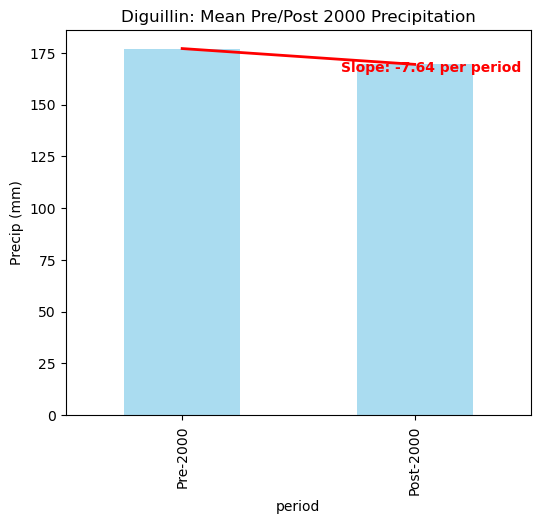


--- Pre/Post 2000 Temp Means for Diguillin ---
period
Post-2000    12.191540
Pre-2000     11.802947
Name: tmean, dtype: float64


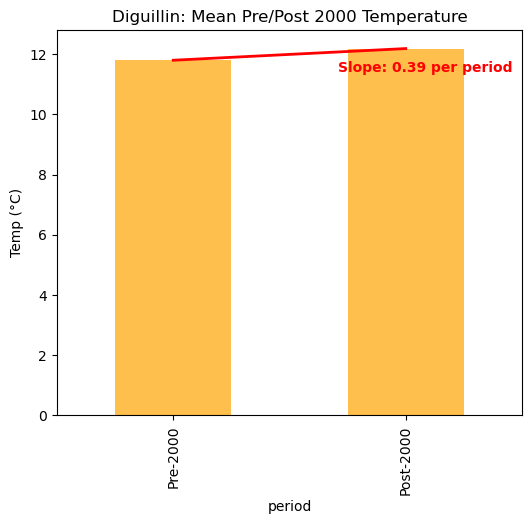


--- Pre/Post 2000 Precip Means for Las Trancas ---
period
Post-2000    142.221698
Pre-2000     195.135246
Name: precip, dtype: float64


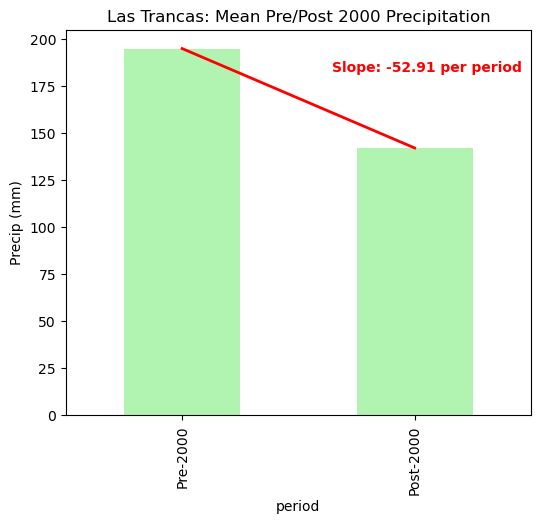

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

date_column = "date"

# ------------------- FILE PATHS -------------------
station_files = {
    "Diguillin": {
        "precip": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Diguillin_codigo[C08130006].csv",
        "tmax": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/temp_max_diguillin.csv",
        "tmin": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/temp_min_diguillin.csv"
    },
    "Las Trancas": {
        "precip": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Las Trancas_codigo[C08130004].csv"
    }
}

# ------------------- FUNCTIONS -------------------

def load_precip(filepath):
    df = pd.read_csv(filepath)
    df[date_column] = pd.to_datetime(df.iloc[:, 0], errors="coerce")
    df["precip"] = df.iloc[:, 1].replace(-9999, np.nan)
    df = df.dropna(subset=["precip", date_column])
    df["year"] = df[date_column].dt.year
    return df

def load_temp(filepath):
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip().str.lower()
    df[date_column] = pd.to_datetime(
        df[["agno","mes","dia"]].astype(str).agg("-".join, axis=1), errors="coerce"
    )
    df["valor"] = df["valor"].replace(-9999, np.nan)
    df = df.dropna(subset=["valor", date_column])
    df["year_month"] = df[date_column].dt.to_period("M")
    df_monthly = df.groupby("year_month")["valor"].mean().reset_index()
    df_monthly[date_column] = df_monthly["year_month"].dt.to_timestamp()
    return df_monthly.rename(columns={"valor":"temp"})

def assign_period(year):
    return "Pre-2000" if year < 2000 else "Post-2000"

def compute_period_means_precip(df_precip, label):
    df_precip["period"] = df_precip["year"].apply(assign_period)
    period_precip = df_precip.groupby("period")["precip"].mean()
    print(f"\n--- Pre/Post 2000 Precip Means for {label} ---")
    print(period_precip)
    return period_precip

def compute_period_means_temp(df_tmax, df_tmin, label):
    df_tmean = pd.merge(df_tmax, df_tmin, on=[date_column,"year_month"], suffixes=("_tmax","_tmin"))
    df_tmean["tmean"] = (df_tmean["temp_tmax"] + df_tmean["temp_tmin"])/2
    df_tmean["year"] = df_tmean[date_column].dt.year
    df_tmean["period"] = df_tmean["year"].apply(assign_period)
    period_temp = df_tmean.groupby("period")["tmean"].mean()
    print(f"\n--- Pre/Post 2000 Temp Means for {label} ---")
    print(period_temp)
    return period_temp

def plot_period_bar(period_series, ylabel, title, color="skyblue"):
    # Ensure Pre-2000 comes first
    period_series = period_series.reindex(["Pre-2000", "Post-2000"])
    
    fig, ax = plt.subplots(figsize=(6,5))
    period_series.plot(kind="bar", color=color, alpha=0.7, ax=ax)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    
    # Add trendline
    x = np.arange(len(period_series))
    y = period_series.values
    slope, intercept = np.polyfit(x, y, 1)
    ax.plot(x, intercept + slope*x, color="red", lw=2)
    ax.text(0.98, 0.92, f"Slope: {slope:.2f} per period", transform=ax.transAxes,
            ha="right", va="top", color="red", fontsize=10, fontweight="bold")
    plt.show()


# ------------------- RUN ANALYSIS -------------------

# 1. Diguillin Precip
df_precip_dig = load_precip(station_files["Diguillin"]["precip"])
period_precip_dig = compute_period_means_precip(df_precip_dig, "Diguillin")
plot_period_bar(period_precip_dig, "Precip (mm)", "Diguillin: Mean Pre/Post 2000 Precipitation")

# 2. Diguillin Temp
df_tmax_dig = load_temp(station_files["Diguillin"]["tmax"])
df_tmin_dig = load_temp(station_files["Diguillin"]["tmin"])
period_temp_dig = compute_period_means_temp(df_tmax_dig, df_tmin_dig, "Diguillin")
plot_period_bar(period_temp_dig, "Temp (°C)", "Diguillin: Mean Pre/Post 2000 Temperature", color="orange")

# 3. Las Trancas Precip
df_precip_lt = load_precip(station_files["Las Trancas"]["precip"])
period_precip_lt = compute_period_means_precip(df_precip_lt, "Las Trancas")
plot_period_bar(period_precip_lt, "Precip (mm)", "Las Trancas: Mean Pre/Post 2000 Precipitation", color="lightgreen")


## Timeseries analysis of precip and temp station data: 


=== Temperature analysis: Diguillin ===
Tmax: slope=0.01/yr, MK p=0.07540740892518949, significant
Tmin: slope=0.02/yr, MK p=0.0, significant
Tmean: slope=0.02/yr, MK p=9.276192924900784e-09, significant


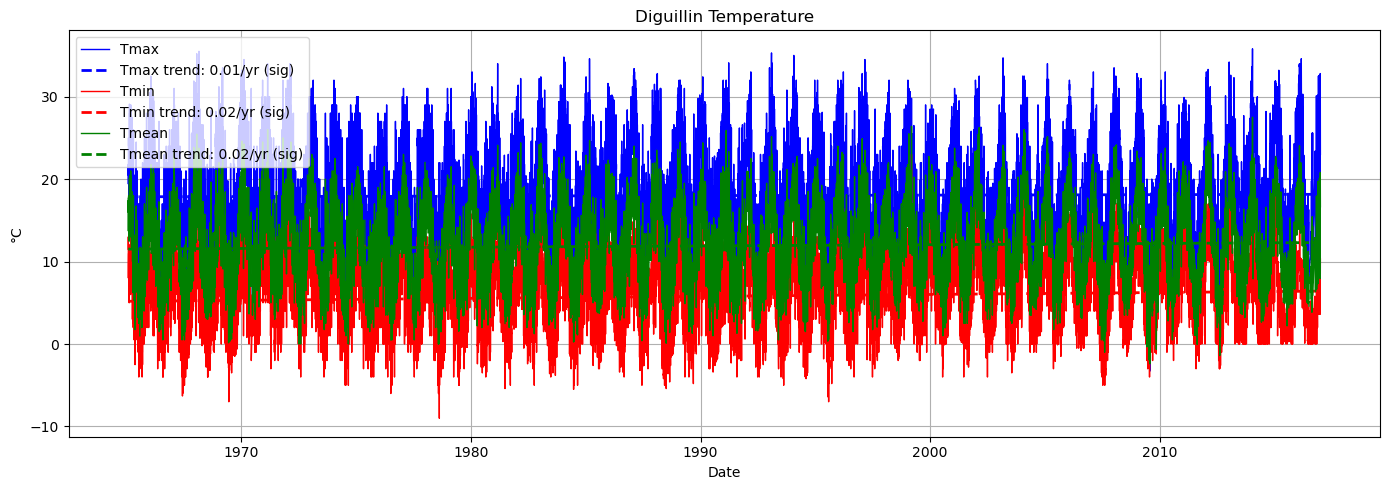


=== Precipitation analysis: Diguillin ===
Diguillin Precip: slope=-1.28/yr, MK p=0.11418692547453557, not significant


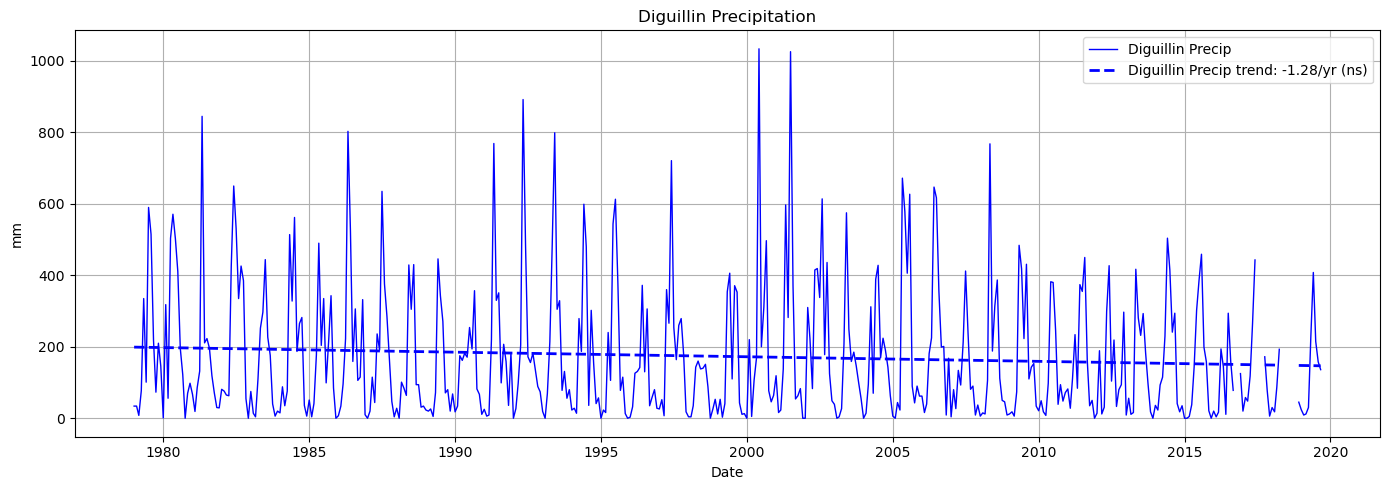


=== Precipitation analysis: Las Trancas ===
Las Trancas Precip: slope=-3.59/yr, MK p=4.789328961329886e-05, significant


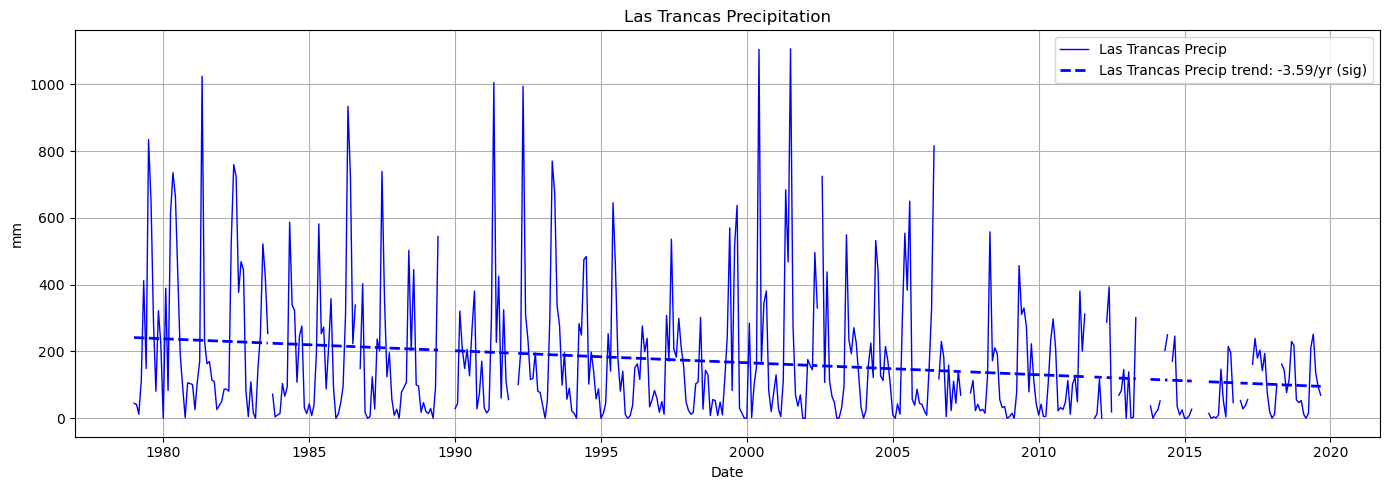

In [15]:
# ------------------- FILE PATHS -------------------

# Temperature station (Diguillin)
temp_stations = {
    "Diguillin": {
        "Tmax": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/temp_max_diguillin.csv",
        "Tmin": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/temp_min_diguillin.csv"
    }
}

# Precipitation stations
precip_stations = {
    "Diguillin": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Diguillin_codigo[C08130006].csv",
    "Las Trancas": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Las Trancas_codigo[C08130004].csv"
}

# ------------------- FUNCTIONS -------------------

def load_temp_csv(filepath):
    """Load daily temperature CSV with columns agno, mes, dia, valor."""
    df = pd.read_csv(filepath, sep=None, engine='python')  # auto-detect separator
    df.rename(columns=lambda x: x.strip(), inplace=True)
    for col in ["agno","mes","dia","valor"]:
        if col not in df.columns:
            raise KeyError(f"Expected column {col} not found in {filepath}")
    df["Fecha"] = pd.to_datetime(dict(year=df["agno"], month=df["mes"], day=df["dia"]))
    df.set_index("Fecha", inplace=True)
    df = df["valor"].rename(filepath.split("/")[-1])
    return df

def load_precip_csv(filepath):
    """Load monthly precipitation CSV and filter out -9999."""
    df = pd.read_csv(filepath, parse_dates=["Fecha"])
    df.rename(columns=lambda x: x.strip(), inplace=True)
    # Assume first numeric column after 'Fecha' is the measurement
    val_col = df.columns[1]
    df[val_col] = pd.to_numeric(df[val_col], errors='coerce')
    df[val_col].replace(-9999, np.nan, inplace=True)
    df.set_index("Fecha", inplace=True)
    return df[val_col]

def compute_trend(series):
    """Compute linear regression trend and Mann-Kendall test."""
    valid = series.dropna()
    if len(valid) < 2:
        return pd.Series(np.nan, index=series.index), 0, None
    x = valid.index.map(pd.Timestamp.toordinal).values.reshape(-1,1)
    y = valid.values
    model = LinearRegression()
    model.fit(x, y)
    slope_per_year = model.coef_[0] * 365.25
    mk_res = mk.original_test(y)
    
    trend_line = pd.Series(index=series.index, dtype=float)
    trend_line[valid.index] = model.predict(x)
    return trend_line, slope_per_year, mk_res

def plot_timeseries(series_dict, title, ylabel):
    """Plot multiple series with trendlines."""
    plt.figure(figsize=(14,5))
    colors = ['blue','red','green','orange','purple','brown','cyan']
    for i, (label, series) in enumerate(series_dict.items()):
        trend_line, slope, mk_res = compute_trend(series)
        plt.plot(series.index, series, color=colors[i%len(colors)], lw=1, label=label)
        plt.plot(trend_line.index, trend_line, '--', color=colors[i%len(colors)],
                 lw=2, label=f"{label} trend: {slope:.2f}/yr ({'sig' if mk_res and mk_res.p<0.1 else 'ns'})")
        print(f"{label}: slope={slope:.2f}/yr, MK p={mk_res.p if mk_res else 'NA'}, {'significant' if mk_res and mk_res.p<0.1 else 'not significant'}")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ------------------- RUN ANALYSIS -------------------

# 1. Temperature analysis
for station_name, paths in temp_stations.items():
    print(f"\n=== Temperature analysis: {station_name} ===")
    df_max = load_temp_csv(paths["Tmax"])
    df_min = load_temp_csv(paths["Tmin"])
    df_mean = (df_max + df_min) / 2
    temp_dict = {"Tmax": df_max, "Tmin": df_min, "Tmean": df_mean}
    plot_timeseries(temp_dict, f"{station_name} Temperature", "°C")

# 2. Precipitation analysis
for station_name, path in precip_stations.items():
    print(f"\n=== Precipitation analysis: {station_name} ===")
    precip_series = load_precip_csv(path)
    plot_timeseries({f"{station_name} Precip": precip_series}, f"{station_name} Precipitation", "mm")


## Comparing decades

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import pymannkendall as mk

# ------------------- FILE PATHS -------------------

temp_stations = {
    "Diguillin": {
        "Tmax": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/temp_max_diguillin.csv",
        "Tmin": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/temp_min_diguillin.csv"
    }
}

precip_stations = {
    "Diguillin": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Diguillin_codigo[C08130006].csv",
    "Las Trancas": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Las Trancas_codigo[C08130004].csv"
}

# ------------------- FUNCTIONS -------------------

def load_temp_csv(filepath):
    """Load daily temperature CSV with columns agno, mes, dia, valor."""
    df = pd.read_csv(filepath, sep=None, engine='python')
    df.rename(columns=lambda x: x.strip(), inplace=True)
    df["Fecha"] = pd.to_datetime(dict(year=df["agno"], month=df["mes"], day=df["dia"]))
    df.set_index("Fecha", inplace=True)
    return df["valor"].replace(-9999, np.nan)

def load_precip_csv(filepath):
    """Load monthly precipitation CSV and filter out -9999."""
    df = pd.read_csv(filepath, parse_dates=["Fecha"])
    df.rename(columns=lambda x: x.strip(), inplace=True)
    val_col = df.columns[1]
    df[val_col] = pd.to_numeric(df[val_col], errors='coerce')
    return df.set_index("Fecha")[val_col].replace(-9999, np.nan)

def compute_decadal_trends(series, ylabel):
    """Split into decades, compute slope + Mann-Kendall."""
    results = []
    for decade_start in [1980, 1990, 2000, 2010]:
        decade_end = decade_start + 9
        mask = (series.index.year >= decade_start) & (series.index.year <= decade_end)
        subset = series[mask].dropna()
        if len(subset) < 2:
            results.append((decade_start, decade_end, np.nan, np.nan, "no data"))
            continue

        # Linear regression slope (per year)
        x = subset.index.map(pd.Timestamp.toordinal).values.reshape(-1,1)
        y = subset.values
        model = LinearRegression().fit(x, y)
        slope = model.coef_[0] * 365.25  # per year

        # Mann-Kendall test
        mk_res = mk.original_test(y)
        sig = "sig" if mk_res.p < 0.1 else "ns"

        results.append((decade_start, decade_end, slope, mk_res.p, sig))
    
    # Print results
    print(f"\n--- {ylabel} ---")
    for r in results:
        print(f"{r[0]}–{r[1]}: slope={r[2]:.3f}/yr, p={r[3]:.3f}, {r[4]}")
    
    return results

# ------------------- RUN ANALYSIS -------------------

# Temperature
for station_name, paths in temp_stations.items():
    print(f"\n=== Temperature analysis: {station_name} ===")
    df_max = load_temp_csv(paths["Tmax"])
    df_min = load_temp_csv(paths["Tmin"])
    df_mean = (df_max + df_min) / 2
    temp_dict = {"Tmax": df_max, "Tmin": df_min, "Tmean": df_mean}

    for label, series in temp_dict.items():
        compute_decadal_trends(series, f"{station_name} {label}")

# Precipitation
for station_name, path in precip_stations.items():
    print(f"\n=== Precipitation analysis: {station_name} ===")
    precip = load_precip_csv(path)
    compute_decadal_trends(precip, f"{station_name} Precip")



=== Temperature analysis: Diguillin ===

--- Diguillin Tmax ---
1980–1989: slope=0.009/yr, p=0.804, ns
1990–1999: slope=-0.010/yr, p=0.846, ns
2000–2009: slope=-0.077/yr, p=0.169, ns
2010–2019: slope=0.222/yr, p=0.007, sig

--- Diguillin Tmin ---
1980–1989: slope=-0.100/yr, p=0.000, sig
1990–1999: slope=0.129/yr, p=0.000, sig
2000–2009: slope=-0.100/yr, p=0.000, sig
2010–2019: slope=-0.370/yr, p=0.000, sig

--- Diguillin Tmean ---
1980–1989: slope=-0.048/yr, p=0.093, sig
1990–1999: slope=0.060/yr, p=0.034, sig
2000–2009: slope=-0.088/yr, p=0.011, sig
2010–2019: slope=-0.057/yr, p=0.146, ns

=== Precipitation analysis: Diguillin ===

--- Diguillin Precip ---
1980–1989: slope=-8.350/yr, p=0.191, ns
1990–1999: slope=-6.136/yr, p=0.177, ns
2000–2009: slope=-7.634/yr, p=0.464, ns
2010–2019: slope=-1.163/yr, p=0.779, ns

=== Precipitation analysis: Las Trancas ===

--- Las Trancas Precip ---
1980–1989: slope=-12.083/yr, p=0.112, ns
1990–1999: slope=-8.204/yr, p=0.077, sig
2000–2009: slope=-

In [17]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import pymannkendall as mk
import matplotlib.pyplot as plt

# -------------------------
# Helper & loading functions
# -------------------------

def clean_colnames(df):
    df.columns = df.columns.astype(str).str.strip().str.lower()
    return df

def load_temp_csv(filepath):
    """
    Load daily temperature CSV with columns like: agno, mes, dia, valor.
    Returns a monthly series (pd.Series) and annual series (pd.Series).
    """
    df = pd.read_csv(filepath, sep=None, engine='python')  # auto-detect separator
    df = clean_colnames(df)
    # expected columns: 'agno','mes','dia','valor'
    expected = ['agno','mes','dia','valor']
    if not all(c in df.columns for c in expected):
        print(f"[WARN] Expected columns {expected} not all found in {filepath}. Columns found: {list(df.columns)}")
    # construct date; coerce errors
    df['date'] = pd.to_datetime(dict(year=df['agno'], month=df['mes'], day=df['dia']), errors='coerce')
    df['valor'] = pd.to_numeric(df['valor'], errors='coerce')
    df.loc[df['valor'] == -9999, 'valor'] = np.nan
    # drop rows without date or value
    df = df.dropna(subset=['date'])
    # monthly mean
    df.set_index('date', inplace=True)
    monthly = df['valor'].resample('M').mean()
    # annual mean (use calendar year)
    annual = monthly.resample('Y').mean()
    # convert annual index to integer year
    annual.index = annual.index.year
    monthly.index = monthly.index.to_period('M').to_timestamp()
    return monthly, annual

def load_precip_csv(filepath):
    """
    Load precipitation CSV. Tries to detect date column and numeric value column.
    Returns monthly series (pd.Series) and annual series (pd.Series).
    """
    df = pd.read_csv(filepath, sep=None, engine='python')
    df = clean_colnames(df)
    # try to find date column
    date_col_candidates = [c for c in df.columns if 'date' in c or 'fecha' in c or c=='fecha']
    if not date_col_candidates:
        # try first column
        date_col = df.columns[0]
        print(f"[WARN] No obvious date column found in {filepath}; using first column '{date_col}' as date.")
    else:
        date_col = date_col_candidates[0]
    # parse dates
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    # find numeric columns (value columns)
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if not numeric_cols:
        # try to coerce second column to numeric
        val_col = df.columns[1]
        df[val_col] = pd.to_numeric(df[val_col], errors='coerce')
        numeric_cols = [val_col]
    val_col = numeric_cols[0]
    # mask -9999
    df[val_col] = df[val_col].replace(-9999, np.nan)
    df = df.dropna(subset=[date_col])
    df.set_index(date_col, inplace=True)
    # if monthly already: resample to month and take mean; then produce annual sum
    monthly = df[val_col].resample('M').sum()
    annual = monthly.resample('Y').sum()
    annual.index = annual.index.year
    monthly.index = monthly.index.to_period('M').to_timestamp()
    return monthly, annual

# -------------------------
# Decadal trend computation
# -------------------------

def compute_decadal_trends_from_annual(series_annual, label="", min_year=1980, max_year=2019):
    """
    series_annual: pd.Series indexed by integer year (e.g., 1980, 1981, ...)
    Returns a DataFrame with decade, slope (per year), mk_p, significant boolean
    """
    results = []
    # ensure index are ints (years)
    ser = series_annual.dropna()
    if ser.index.dtype != np.int64 and ser.index.dtype != np.int32:
        try:
            ser.index = ser.index.astype(int)
        except Exception:
            ser.index = pd.Index([int(x.year) for x in ser.index])
    decades = [1980, 1990, 2000, 2010]
    for d in decades:
        start, end = d, d + 9
        mask = (ser.index >= start) & (ser.index <= end)
        subset = ser.loc[mask].dropna()
        if len(subset) < 3:
            results.append({'decade': f"{start}s", 'n': len(subset),
                            'slope_per_year': np.nan, 'mk_p': np.nan, 'significant': False})
            continue
        # OLS slope on years
        X = subset.index.values.reshape(-1,1)  # years: 1980,1981,...
        y = subset.values
        model = LinearRegression().fit(X, y)
        slope = model.coef_[0]  # units per year (because X is years)
        # Mann-Kendall on the raw annual series values
        mk_res = mk.original_test(y)
        p = mk_res.p
        sig = p < 0.1
        results.append({'decade': f"{start}s", 'n': len(subset),
                        'slope_per_year': slope, 'mk_p': p, 'significant': sig})
    dfres = pd.DataFrame(results)
    dfres = dfres.set_index('decade')
    print(f"\nDecadal trends for {label} (annual-aggregated):")
    print(dfres)
    return dfres

# -------------------------
# Diagnostics helper
# -------------------------
def diagnose_series(monthly, annual, label):
    print(f"\n--- DIAGNOSTICS: {label} ---")
    print("Monthly (first 8 rows):")
    print(monthly.head(8))
    print("Monthly stats:")
    print(monthly.describe())
    print("Annual (first 8 rows):")
    print(annual.head(8))
    print("Annual stats:")
    print(annual.describe())

# -------------------------
# RUN: Temperature analysis
# -------------------------
for station, paths in {
    "Diguillin": {
        "Tmax": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/temp_max_diguillin.csv",
        "Tmin": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/temp_min_diguillin.csv"
    }
}.items():
    print(f"\n=== Station: {station} ===")
    # load monthly & annual
    tmax_monthly, tmax_annual = load_temp_csv(paths['Tmax'])
    tmin_monthly, tmin_annual = load_temp_csv(paths['Tmin'])

    # Quick diagnostics (look for weird scaling)
    diagnose_series(tmax_monthly, tmax_annual, f"{station} Tmax")
    diagnose_series(tmin_monthly, tmin_annual, f"{station} Tmin")

    # Basic auto-detect scale issues (if median temp > 100 => likely tenths of deg)
    for name, ann in [('Tmax', tmax_annual), ('Tmin', tmin_annual)]:
        med = ann.median(skipna=True)
        if pd.notna(med) and abs(med) > 100:
            print(f"[INFO] {name} annual median = {med:.1f} -> large. Dividing by 10 assuming data in tenths.")
            ann = ann / 10.0
            if name == 'Tmax':
                tmax_annual = ann
                tmax_monthly = tmax_monthly / 10.0
            else:
                tmin_annual = ann
                tmin_monthly = tmin_monthly / 10.0

    # compute Tmean annual
    # align annual indices before averaging
    tmean_annual = pd.concat([tmax_annual, tmin_annual], axis=1).mean(axis=1)
    # diagnose Tmean
    print("\n-- Tmean diagnostics --")
    diagnose_series((tmax_monthly + tmin_monthly)/2, tmean_annual, f"{station} Tmean")

    # compute decadal trends on annual series
    print("\nTemperature decadal results:")
    for lab, ann_series in [('Tmax', tmax_annual), ('Tmin', tmin_annual), ('Tmean', tmean_annual)]:
        compute_decadal_trends_from_annual(ann_series, label=f"{station} {lab}")

# -------------------------
# RUN: Precipitation analysis
# -------------------------
for station, path in {
    "Diguillin": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Diguillin_codigo[C08130006].csv",
    "Las Trancas": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Las Trancas_codigo[C08130004].csv"
}.items():
    print(f"\n=== Precip station: {station} ===")
    monthly_prec, annual_prec = load_precip_csv(path)
    diagnose_series(monthly_prec, annual_prec, f"{station} Precip (monthly sum, annual total)")

    # If annual totals seem extremely large or small, you'll see it in the stats above.
    compute_decadal_trends_from_annual(annual_prec, label=f"{station} Precip")



=== Station: Diguillin ===

--- DIAGNOSTICS: Diguillin Tmax ---
Monthly (first 8 rows):
date
1965-01-01    20.566667
1965-02-01    23.917857
1965-03-01    23.793333
1965-04-01    16.803333
1965-05-01    12.838710
1965-06-01    14.116667
1965-07-01     9.900000
1965-08-01    11.064516
Freq: MS, Name: valor, dtype: float64
Monthly stats:
count    622.000000
mean      18.036161
std        5.203558
min        6.261290
25%       13.548526
50%       17.510000
75%       22.782903
max       28.403226
Name: valor, dtype: float64
Annual (first 8 rows):
date
1965    16.734267
1966    17.082244
1967    17.373614
1968    18.093543
1969    17.440662
1970    19.304578
1971    18.905063
1972    18.250701
Name: valor, dtype: float64
Annual stats:
count    52.000000
mean     18.042430
std       0.745083
min      16.433360
25%      17.588015
50%      18.109311
75%      18.531087
max      19.992143
Name: valor, dtype: float64

--- DIAGNOSTICS: Diguillin Tmin ---
Monthly (first 8 rows):
date
1965-01-01   

## Simple OLS analysis of CAMELS-C: gridded data (no pre-whitening):


=== Temperature analysis: Diguillin ===
Tmax: slope=0.01/yr, MK p=0.07540740892518949, significant
Tmin: slope=0.02/yr, MK p=0.0, significant
Tmean: slope=0.03/yr, MK p=9.276192924900784e-09, significant


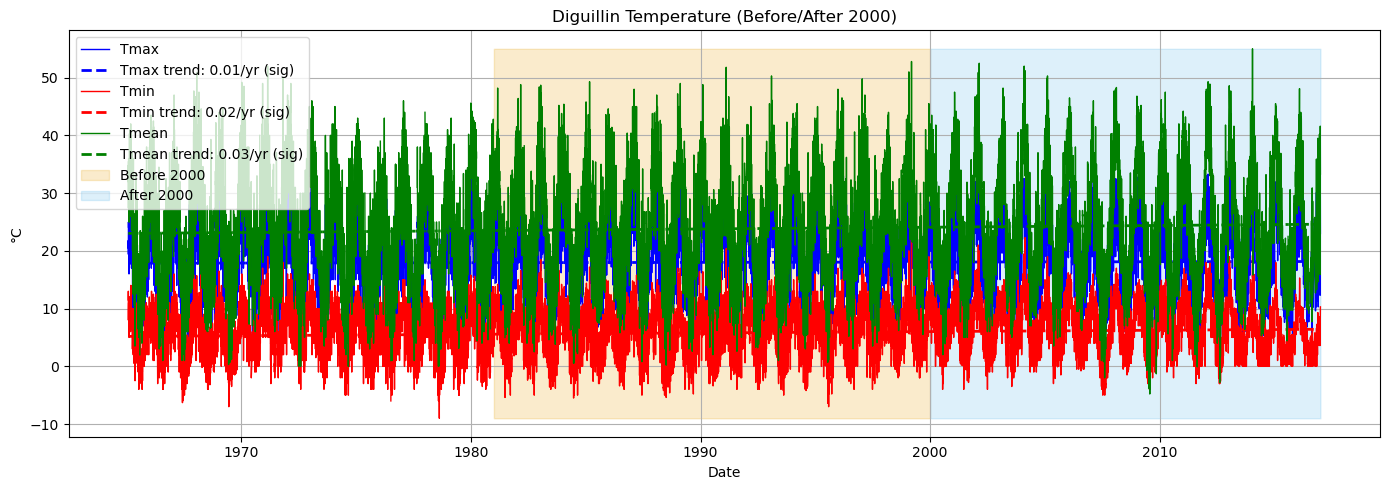

Tmax: slope=0.01/yr, MK p=0.07540740892518949, significant
Tmin: slope=0.02/yr, MK p=0.0, significant
Tmean: slope=0.03/yr, MK p=9.276192924900784e-09, significant


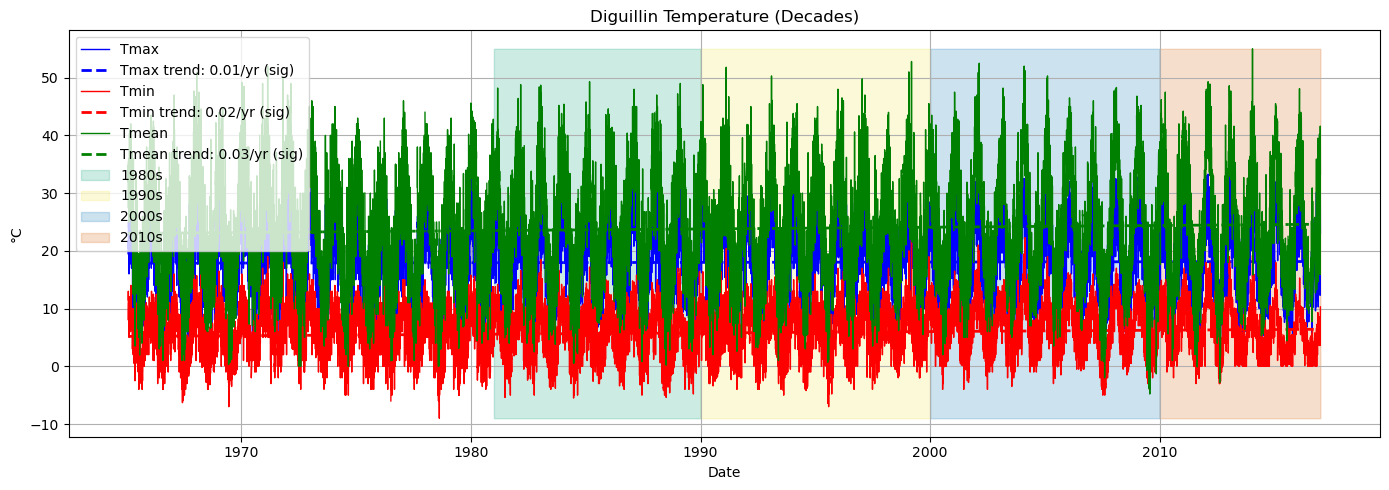


=== Precipitation analysis: Diguillin ===
Estacion_mm: slope=-1.28/yr, MK p=0.11418692547453557, not significant
CR2MET_v2_mm: slope=-1.36/yr, MK p=0.16110221791559942, not significant
CR2MET_v2.5_beta_mm: slope=-1.55/yr, MK p=0.12706451160067234, not significant
MSWEP_v2.8_mm: slope=-0.97/yr, MK p=0.06069569490450699, significant


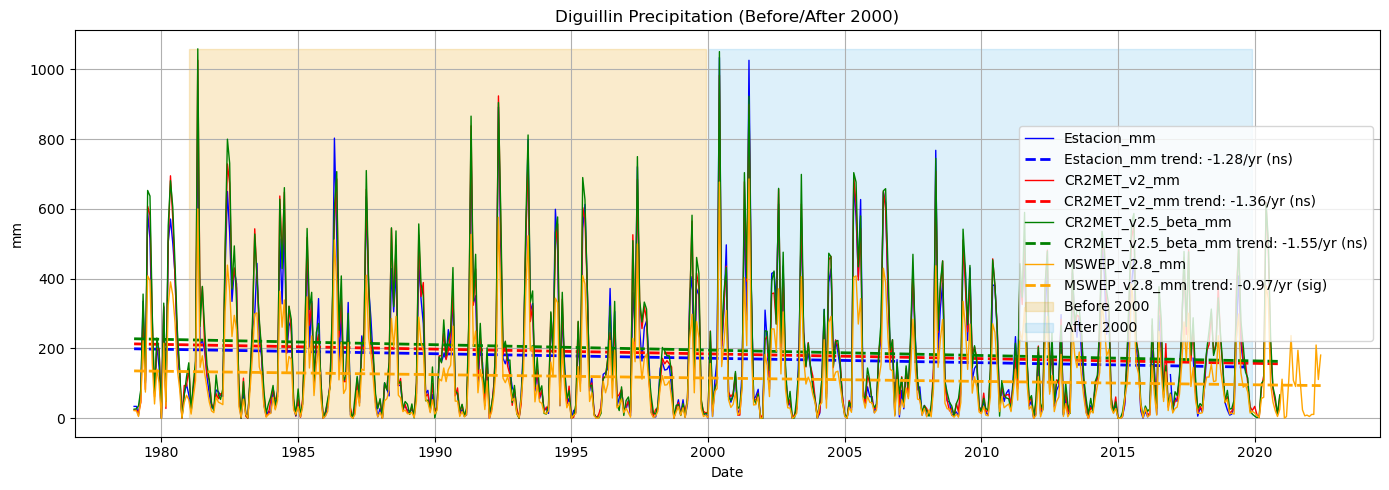

Estacion_mm: slope=-1.28/yr, MK p=0.11418692547453557, not significant
CR2MET_v2_mm: slope=-1.36/yr, MK p=0.16110221791559942, not significant
CR2MET_v2.5_beta_mm: slope=-1.55/yr, MK p=0.12706451160067234, not significant
MSWEP_v2.8_mm: slope=-0.97/yr, MK p=0.06069569490450699, significant


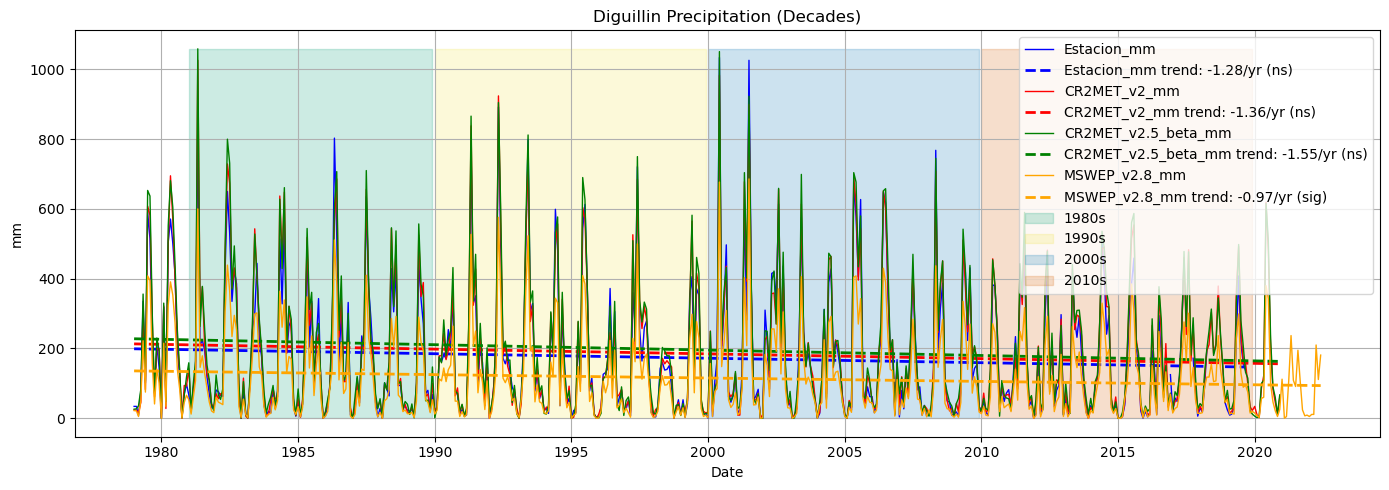


=== Precipitation analysis: Las Trancas ===
Estacion_mm: slope=-3.59/yr, MK p=4.789328961329886e-05, significant
CR2MET_v2_mm: slope=-1.57/yr, MK p=0.15617821852370106, not significant
CR2MET_v2.5_beta_mm: slope=-1.65/yr, MK p=0.13538219221268166, not significant
MSWEP_v2.8_mm: slope=-1.11/yr, MK p=0.05030680413542643, significant


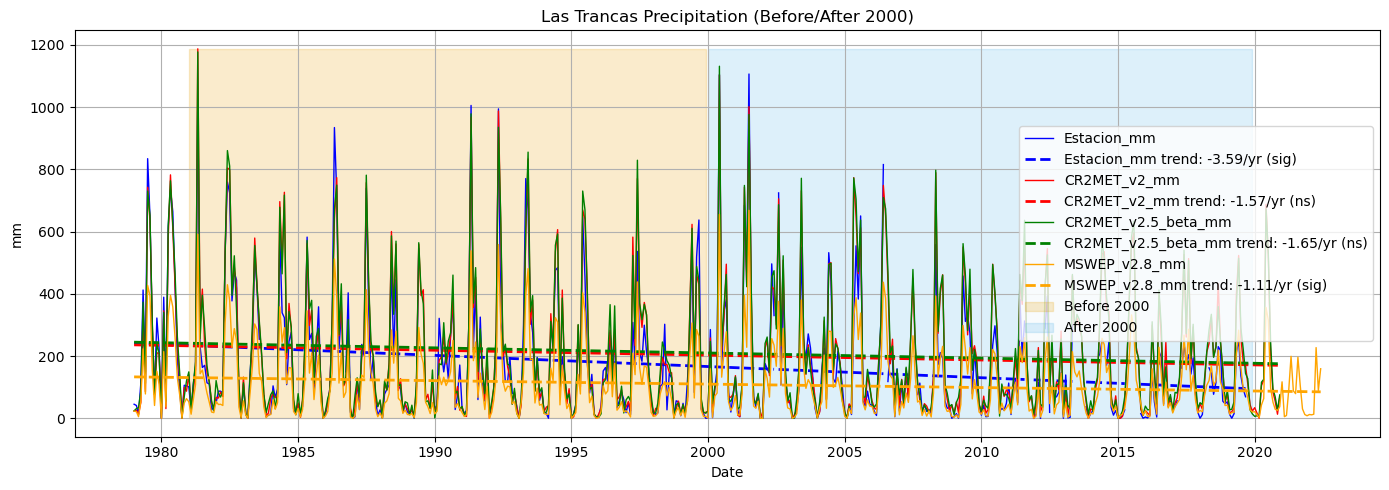

Estacion_mm: slope=-3.59/yr, MK p=4.789328961329886e-05, significant
CR2MET_v2_mm: slope=-1.57/yr, MK p=0.15617821852370106, not significant
CR2MET_v2.5_beta_mm: slope=-1.65/yr, MK p=0.13538219221268166, not significant
MSWEP_v2.8_mm: slope=-1.11/yr, MK p=0.05030680413542643, significant


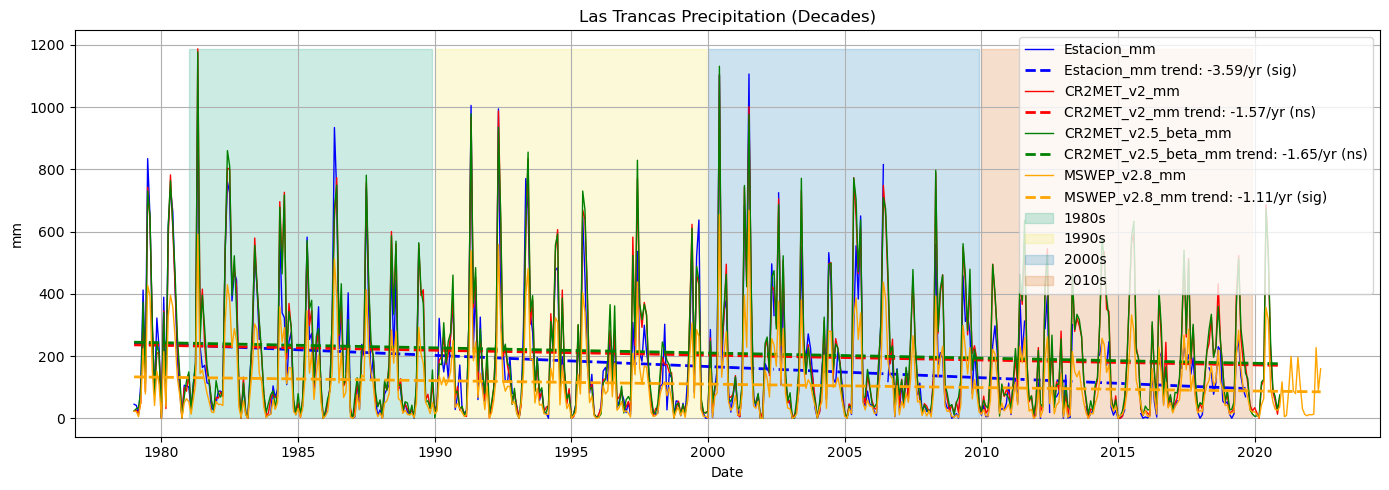

In [18]:
# ------------------- FILE PATHS -------------------

# Temperature station (Diguillin)
temp_stations = {
    "Diguillin": {
        "Tmax": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/temp_max_diguillin.csv",
        "Tmin": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/temp_min_diguillin.csv"
    }
}

# Precipitation stations
precip_stations = {
    "Diguillin": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Diguillin_codigo[C08130006].csv",
    "Las Trancas": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Las Trancas_codigo[C08130004].csv"
}

# Precipitation columns to include
precip_columns = ["Estacion_mm", "CR2MET_v2_mm", "CR2MET_v2.5_beta_mm", "MSWEP_v2.8_mm"]

# ------------------- PERIODS -------------------
cb_palette = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#999999']

before_after_2000 = [
    (pd.Timestamp('1981-01-01'), pd.Timestamp('1999-12-31'), 'Before 2000', cb_palette[0]),
    (pd.Timestamp('2000-01-01'), pd.Timestamp('2019-12-31'), 'After 2000', cb_palette[1]),
]

decades = [
    (pd.Timestamp('1981-01-01'), pd.Timestamp('1989-12-31'), '1980s', cb_palette[2]),
    (pd.Timestamp('1990-01-01'), pd.Timestamp('1999-12-31'), '1990s', cb_palette[3]),
    (pd.Timestamp('2000-01-01'), pd.Timestamp('2009-12-31'), '2000s', cb_palette[4]),
    (pd.Timestamp('2010-01-01'), pd.Timestamp('2019-12-31'), '2010s', cb_palette[5]),
]

# ------------------- FUNCTIONS -------------------

def load_temp_csv(filepath):
    """Load daily temperature CSV with columns agno, mes, dia, valor."""
    df = pd.read_csv(filepath, sep=None, engine='python')  # auto-detect separator
    df.rename(columns=lambda x: x.strip(), inplace=True)
    for col in ["agno","mes","dia","valor"]:
        if col not in df.columns:
            raise KeyError(f"Expected column {col} not found in {filepath}")
    df["Fecha"] = pd.to_datetime(dict(year=df["agno"], month=df["mes"], day=df["dia"]))
    df.set_index("Fecha", inplace=True)
    return df["valor"]

def load_precip_csv(filepath, columns):
    """Load monthly precipitation CSV and filter out -9999."""
    df = pd.read_csv(filepath, parse_dates=["Fecha"])
    df.rename(columns=lambda x: x.strip(), inplace=True)
    df.set_index("Fecha", inplace=True)
    df = df[columns].replace(-9999, np.nan)
    return df

def compute_trend(series):
    """Compute linear regression trend and Mann-Kendall test."""
    valid = series.dropna()
    if len(valid) < 2:
        return pd.Series(np.nan, index=series.index), 0, None
    x = valid.index.map(pd.Timestamp.toordinal).values.reshape(-1,1)
    y = valid.values
    model = LinearRegression()
    model.fit(x, y)
    slope_per_year = model.coef_[0] * 365.25
    trend_line = pd.Series(index=series.index, dtype=float)
    trend_line[valid.index] = model.predict(x)
    mk_res = mk.original_test(y)
    return trend_line, slope_per_year, mk_res

def plot_with_trends_and_periods(df, title, ylabel, periods):
    """Plot multiple series with trendlines and shaded periods."""
    plt.figure(figsize=(14,5))
    colors = ['blue','red','green','orange','purple','brown','cyan']
    for i, col in enumerate(df.columns):
        series = df[col]
        trend_line, slope, mk_res = compute_trend(series)
        plt.plot(series.index, series, color=colors[i%len(colors)], lw=1, label=col)
        plt.plot(trend_line.index, trend_line, '--', color=colors[i%len(colors)],
                 lw=2, label=f"{col} trend: {slope:.2f}/yr ({'sig' if mk_res and mk_res.p<0.1 else 'ns'})")
        print(f"{col}: slope={slope:.2f}/yr, MK p={mk_res.p if mk_res else 'NA'}, {'significant' if mk_res and mk_res.p<0.1 else 'not significant'}")
    
    # Shaded periods
    series_min = df.min().min()
    series_max = df.max().max()
    for i, (start, end, label, col) in enumerate(periods):
        plt.fill_between(df.index, series_min, series_max,
                         where=(df.index>=start) & (df.index<=end),
                         color=col, alpha=0.2, label=label)
    
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ------------------- RUN ANALYSIS -------------------

# 1. Temperature analysis
for station_name, paths in temp_stations.items():
    print(f"\n=== Temperature analysis: {station_name} ===")
    df_max = load_temp_csv(paths["Tmax"]).rename("Tmax")
    df_min = load_temp_csv(paths["Tmin"]).rename("Tmin")
    df_mean = (df_max + df_min).rename("Tmean")
    temp_df = pd.concat([df_max, df_min, df_mean], axis=1)
    
    # Plot Before/After 2000
    plot_with_trends_and_periods(temp_df, f"{station_name} Temperature (Before/After 2000)", "°C", before_after_2000)
    
    # Plot decadal means
    plot_with_trends_and_periods(temp_df, f"{station_name} Temperature (Decades)", "°C", decades)

# 2. Precipitation analysis
for station_name, path in precip_stations.items():
    print(f"\n=== Precipitation analysis: {station_name} ===")
    precip_df = load_precip_csv(path, precip_columns)
    
    # Plot Before/After 2000
    plot_with_trends_and_periods(precip_df, f"{station_name} Precipitation (Before/After 2000)", "mm", before_after_2000)
    
    # Plot decadal means
    plot_with_trends_and_periods(precip_df, f"{station_name} Precipitation (Decades)", "mm", decades)
